In [34]:
with rasterio.open(r"C:\Users\rkoe799\Documents\PhD\DATA\bath\bath_raoul\Elevation1.tif") as src:
    print(src.crs)

EPSG:32760


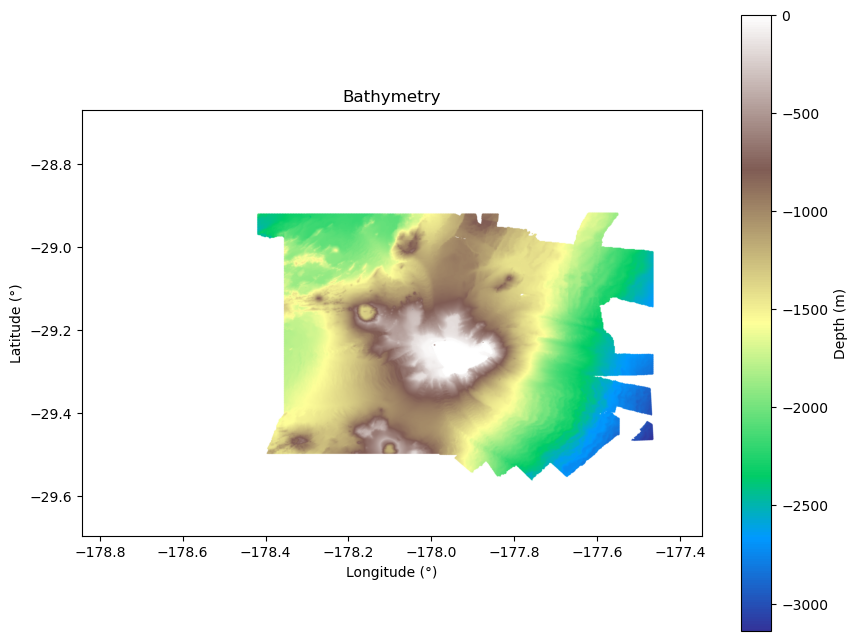

In [35]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import numpy as np
import matplotlib.pyplot as plt

fname = r"C:\Users\rkoe799\Documents\PhD\DATA\bath\bath_raoul\Elevation1.tif"

with rasterio.open(fname) as src:

    transform, width, height = calculate_default_transform(
        src.crs,
        "EPSG:4326",
        src.width,
        src.height,
        *src.bounds
    )

    bathy = np.empty((height, width), dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=bathy,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=transform,
        dst_crs="EPSG:4326",
        resampling=Resampling.bilinear
    )

bounds = array_bounds(height, width, transform)

plt.figure(figsize=(10, 8))

img = plt.imshow(
    bathy,
    extent=[bounds[0], bounds[2], bounds[1], bounds[3]],
    origin="upper",
    cmap="terrain",
    vmin=-3140,
    vmax=0
)

plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")
plt.colorbar(img, label="Depth (m)")
plt.title("Bathymetry")
plt.show()


In [36]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import xarray as xr

fname = r"C:\Users\rkoe799\Documents\PhD\DATA\bath\bath_raoul\Elevation1.tif"

with rasterio.open(fname) as src:

    transform, width, height = calculate_default_transform(
        src.crs,
        "EPSG:4326",
        src.width,
        src.height,
        *src.bounds
    )

    bathy = np.empty((height, width), dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=bathy,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=transform,
        dst_crs="EPSG:4326",
        resampling=Resampling.bilinear
    )

# Calculate coordinate vectors from affine transform
lon = transform.c + (np.arange(width) + 0.5) * transform.a
lat = transform.f + (np.arange(height) + 0.5) * transform.e

# If latitude is decreasing (common for rasters), flip so lat is ascending
if lat[0] > lat[-1]:
    lat = lat[::-1]
    bathy = bathy[::-1, :]

# Create xarray Dataset
ds = xr.Dataset(
    data_vars={
        "depth": (("lat", "lon"), bathy)
    },
    coords={
        "lon": lon,
        "lat": lat
    },
    attrs={
        "title": "Raoul Island Bathymetry",
        "crs": "EPSG:4326"
    }
)

# Variable metadata
ds.depth.attrs["long_name"] = "Bathymetric depth"
ds.depth.attrs["units"] = "m"

# Save NetCDF
#outfile = r"C:\Users\rkoe799\Documents\PhD\DATA\bath\bath_raoul\bathymetry.nc"
#ds.to_netcdf(outfile)

#print(f"Saved: {outfile}")
ds

<xarray.Dataset> Size: 101MB
Dimensions:  (lat: 4175, lon: 6072)
Coordinates:
  * lat      (lat) float64 33kB -29.7 -29.7 -29.7 -29.7 ... -28.67 -28.67 -28.67
  * lon      (lon) float64 49kB -178.8 -178.8 -178.8 ... -177.3 -177.3 -177.3
Data variables:
    depth    (lat, lon) float32 101MB 3.4e+38 3.4e+38 ... 3.4e+38 3.4e+38
Attributes:
    title:    Raoul Island Bathymetry
    crs:      EPSG:4326

In [37]:
# Set depths deeper than 3500 m to NaN
ds["depth"] = ds.depth.where(~(ds.depth > 3500 ))
ds.depth.values

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(4175, 6072), dtype=float32)

In [38]:

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean
import pickle
import array
import xarray as xr
import numpy as np 
import pickle
#from seabird.cnv import fCNV
import pandas as pd

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature



In [39]:
import pandas as pd
import numpy as np

path = r"C:\Users\rkoe799\Documents\PhD\CTD\df\dfs.xlsx"

df = pd.read_excel(
    path,
    
    sheet_name="df_23_clean_trans_mooring"
)


In [40]:
df.station_label

0        TMA
1        TMA
2        TMA
3        TMA
4        TMA
        ... 
24708    SW1
24709    SW1
24710    SW1
24711    SW1
24712    SW1
Name: station_label, Length: 24713, dtype: str

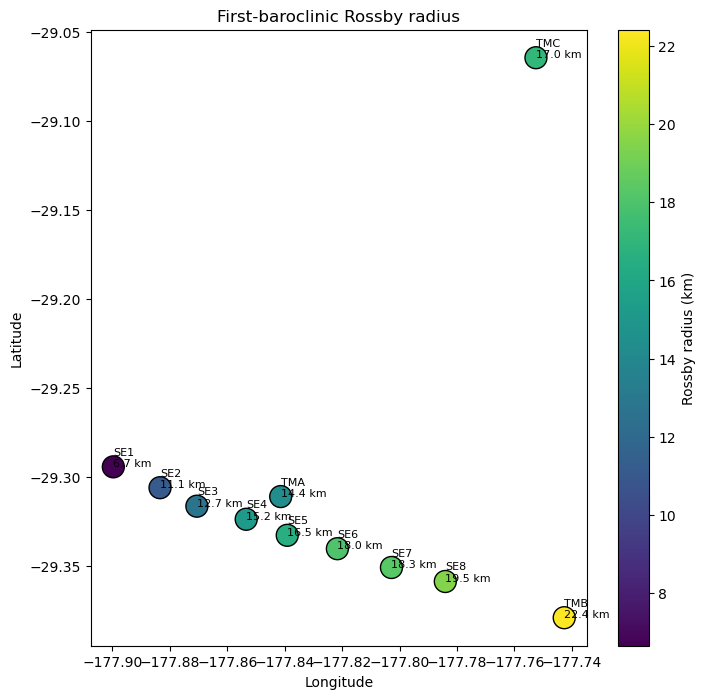

In [13]:
fig, ax = plt.subplots(
    figsize=(8,8)
)

sc = ax.scatter(
    Rd_df["lon"],
    Rd_df["lat"],
    c=Rd_df["Rd_km"],
    s=250,
    cmap="viridis",
    edgecolor="k"
)

for _, r in Rd_df.iterrows():

    ax.text(
        r["lon"],
        r["lat"],
        f"{r['station']}\n{r['Rd_km']:.1f} km",
        fontsize=8,
        ha="left"
    )

cb = plt.colorbar(sc)
cb.set_label(
    "Rossby radius (km)"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title(
    "First-baroclinic Rossby radius"
)

plt.show()

In [8]:
df.station_label

0        TMA
1        TMA
2        TMA
3        TMA
4        TMA
        ... 
24708    SW1
24709    SW1
24710    SW1
24711    SW1
24712    SW1
Name: station_label, Length: 24713, dtype: str

In [41]:
def comma_to_float(s):
    return pd.to_numeric(
        s.astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

numeric_cols = [
    'latitude_deg', 'longitude_deg', 'depth_m',
    'pressure_dbar', 'p_temperature_c',
    'p_salinity_psu',
    'p_sigma0_kgm3_minus_1000'
]

for c in numeric_cols:
    df[c] = comma_to_float(df[c])

stations_keep = [ 'TMB'] + [ 'TMA'] + ['TMC'] + [f'SE{i}' for i in range(1, 9)] 

df = df[df['station_label'].isin(stations_keep)].copy()

stations = (
    df.groupby('station_label')
      .agg(
          lat=('latitude_deg', 'mean'),
          lon=('longitude_deg', 'mean')
      )
      .reset_index()
)

R = 6371e3  # Earth radius [m]

lat0 = np.deg2rad(stations['lat'].mean())
lon0 = np.deg2rad(stations['lon'].mean())

def ll_to_xy(lat, lon):
    lat = np.deg2rad(lat)
    lon = np.deg2rad(lon)
    x = R * (lon - lon0) * np.cos(lat0)
    y = R * (lat - lat0)
    return x, y

stations['x'], stations['y'] = ll_to_xy(
    stations['lat'], stations['lon']
)


xy = stations[['x', 'y']].values
xy_mean = xy.mean(axis=0)
xyc = xy - xy_mean

U, S, Vt = np.linalg.svd(xyc)
transect_dir = Vt[0]   # unit vector along transect


df['x'], df['y'] = ll_to_xy(
    df['latitude_deg'], df['longitude_deg']
)

XY = np.column_stack((df['x'], df['y']))
df['s_m'] = (XY - xy_mean) @ transect_dir

g = 9.81
rho0 = 1025

df['rho'] = 1000 + df['p_sigma0_kgm3_minus_1000']
df['z'] = -df['depth_m']



In [42]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Physical constants
# --------------------------------------------------
g = 9.81
rho0 = 1025.0

omega = 2 * np.pi / (12.42 * 3600)  # M2 tide [rad s^-1]
omega2 = omega**2

# --------------------------------------------------
# Station grouping variable
# --------------------------------------------------
station_col = 'station_label'  # or 'station' if that's the correct one

# --------------------------------------------------
# Coriolis frequency
# --------------------------------------------------
Omega = 7.2921159e-5



df['f'] = 2 * Omega * np.sin(np.deg2rad(df['latitude_deg']))
df['f2'] = df['f']**2

# --------------------------------------------------
# Compute N²
# --------------------------------------------------
def compute_N2(profile):

    profile = profile.sort_values('depth_m').copy()

    depth = profile['depth_m'].to_numpy()
    rho = profile['rho'].to_numpy()

    if len(profile) < 3:
        profile['N2'] = np.nan
        return profile

    drho_dz = np.gradient(rho, depth)

    profile['N2'] = (g / rho0) * drho_dz

    return profile


# --------------------------------------------------
# Vertical smoothing
# --------------------------------------------------
def smooth_N2(profile, window=3):

    profile = profile.sort_values('depth_m').copy()

    profile['N2_smooth'] = (
        profile['N2']
        .rolling(window=window, center=True, min_periods=1)
        .mean()
    )

    return profile




# --------------------------------------------------
# Bottom-averaged N²
# --------------------------------------------------
def bottom_avg_N2(profile, depth_range=5):

    profile = profile.sort_values('depth_m').copy()

    max_depth = profile['depth_m'].max()

    bottom = profile[
        (profile['depth_m'] >= max_depth - depth_range)
        & np.isfinite(profile['N2_smooth'])
    ]

    profile['N2_bottom'] = (
        bottom['N2_smooth'].median()
        if len(bottom) > 0
        else np.nan
    )

    return profile

profiles = []

for station, profile in df.groupby('station_label'):

    profile = compute_N2(profile)

    #profile.loc[profile['N2'] <= omega2, 'N2'] = np.nan

    profile = smooth_N2(profile)

    profile = bottom_avg_N2(profile)

    profiles.append(profile)

df = pd.concat(profiles, ignore_index=True)


# --------------------------------------------------
# M2 internal tide phase speed
# --------------------------------------------------
df['c_M2'] = np.nan

valid = (
    (df['N2_bottom'] > omega2) &
    (omega2 > df['f2'])
)

df.loc[valid, 'c_M2'] = np.sqrt(
    (omega2 - df.loc[valid, 'f2']) /
    (df.loc[valid, 'N2_bottom'] - omega2)
)

In [43]:
# Height above bottom for each CTD profile
df['z_above_bottom'] = np.nan

for st, g in df.groupby('station_label'):
    max_depth = g['depth_m'].max()
    df.loc[g.index, 'z_above_bottom'] = max_depth - g['depth_m']

In [44]:
df_bot = df[
    (df['z_above_bottom'] >= 0) &
    (df['z_above_bottom'] <= 100) &
    (df['N2_smooth'].notna())
].copy()

In [45]:
stations_order = sorted(df_bot['station_label'].unique())
n_stations = len(stations_order)

In [46]:
stations_order

['SE1', 'SE2', 'SE3', 'SE4', 'SE5', 'SE6', 'SE7', 'SE8', 'TMA', 'TMB', 'TMC']

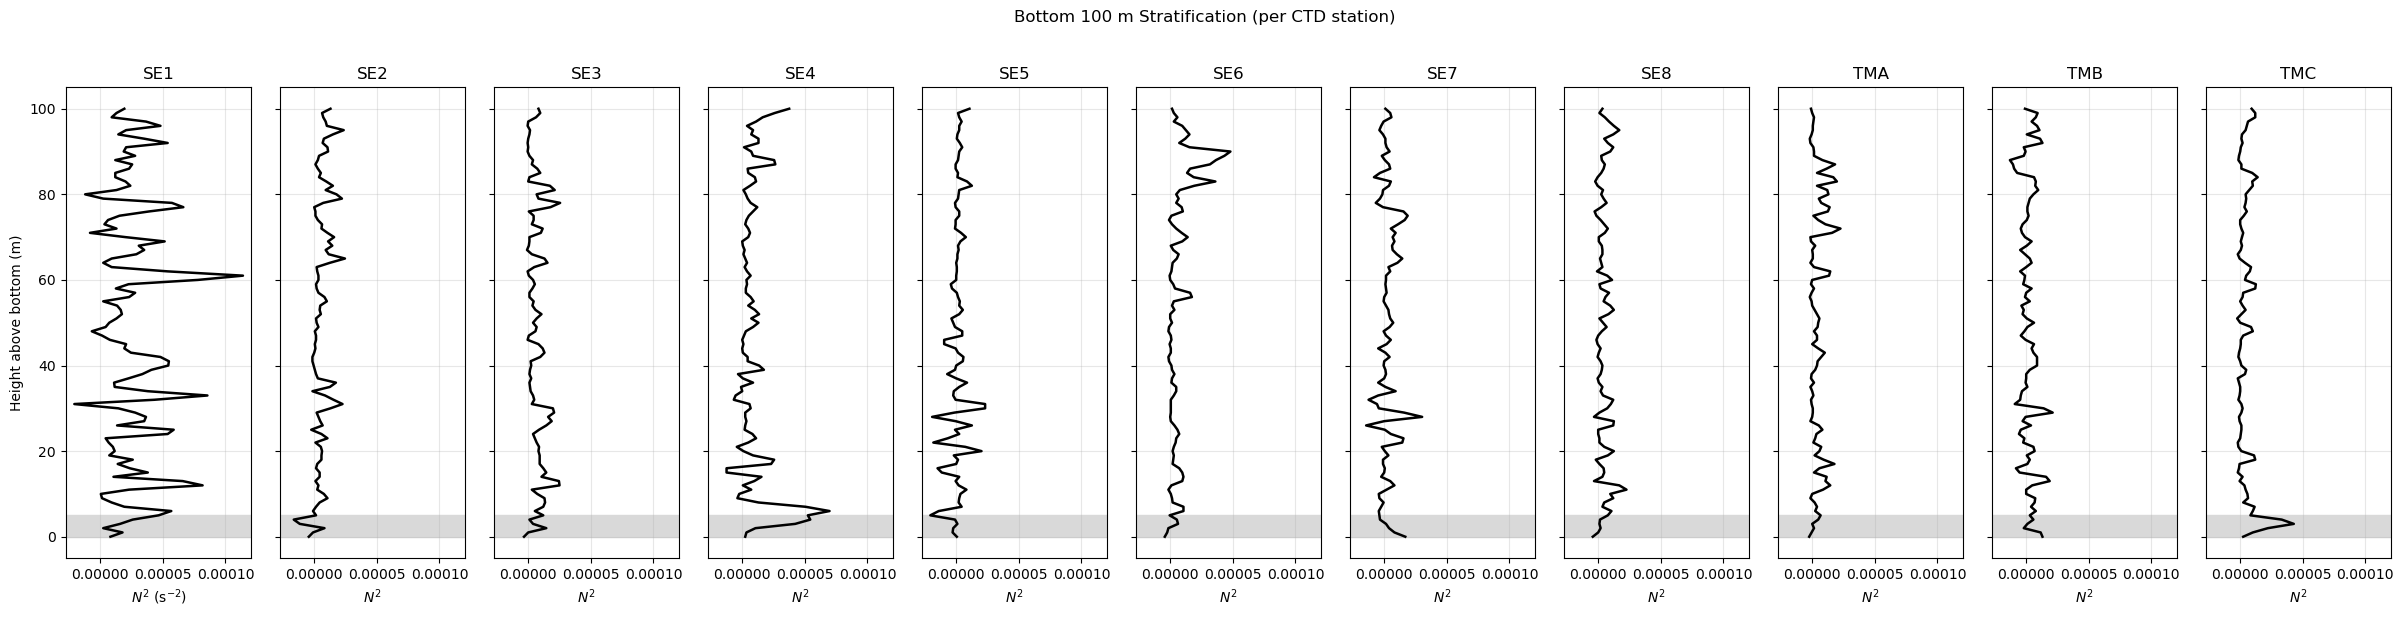

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    n_stations,
    figsize=(2.2 * n_stations, 6),
    sharey=True,
    sharex=True
)

if n_stations == 1:
    axes = [axes]  # make iterable

for ax, st in zip(axes, stations_order):
    g = df_bot[df_bot['station_label'] == st].sort_values('z_above_bottom')

    ax.plot(
        g['N2'],
        g['z_above_bottom'],
        color='k',
        linewidth=1.8
    )

    # Highlight bottom 20 m (your averaging layer)
    ax.axhspan(
        0, 5,
        color='0.85',
        zorder=-1
    )

    ax.set_title(st)
    ax.grid(True, alpha=0.3)

# Shared axes formatting
#axes[0].invert_yaxis()
axes[0].set_ylabel('Height above bottom (m)')
axes[0].set_xlabel(r'$N^2$ (s$^{-2}$)')

for ax in axes[1:]:
    ax.set_xlabel(r'$N^2$')

plt.suptitle('Bottom 100 m Stratification (per CTD station)', y=1.02)
plt.tight_layout()
plt.show()

c:\Users\rkoe799\AppData\Local\anaconda3\envs\marine\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


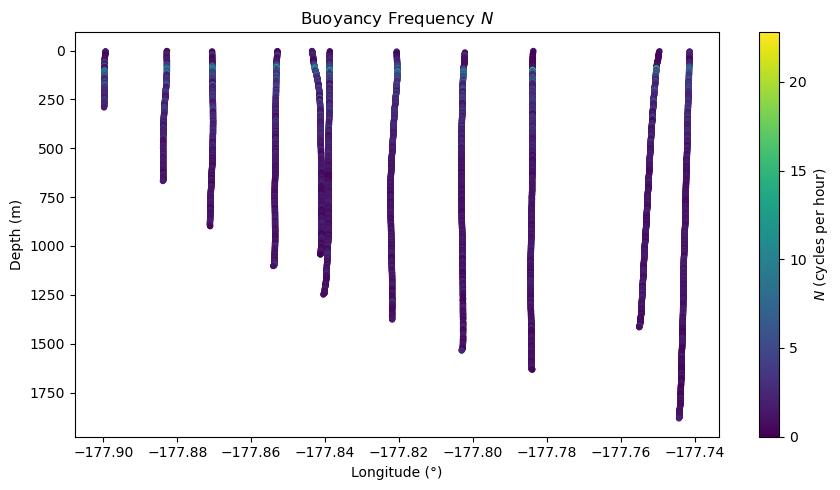

In [48]:
# Compute buoyancy frequency N (1/s)
df['N'] = np.sqrt(df['N2'])

# Convert N to cycles per hour (cph)
df['N_cph'] = df['N'] * 3600 / (2 * np.pi)

import numpy as np
import matplotlib.pyplot as plt

# Keep only valid values
plot_df = df[np.isfinite(df['N_cph'])].copy()

plt.figure(figsize=(9, 5))

sc = plt.scatter(
    plot_df['longitude_deg'],
    plot_df['depth_m'],
    c=plot_df['N_cph'],
    s=12,
    cmap='viridis'
    
)

plt.gca().invert_yaxis()
plt.xlabel('Longitude (°)')
plt.ylabel('Depth (m)')
plt.title('Buoyancy Frequency $N$')

cbar = plt.colorbar(sc)
cbar.set_label('$N$ (cycles per hour)')

plt.tight_layout()
plt.show()


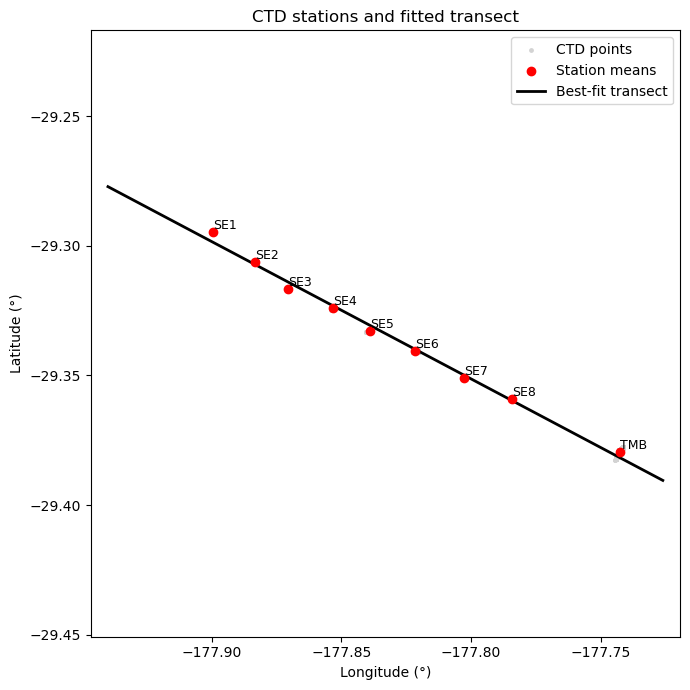

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------------
# Fix decimal commas
# ------------------------------------------------------------------
for c in ['latitude_deg', 'longitude_deg']:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

# ------------------------------------------------------------------
# Select stations
# ------------------------------------------------------------------
stations_keep = ['TMB'] + [f'SE{i}' for i in range(1, 9)]
df_copy = df[df['station_label'].isin(stations_keep)].copy()

# ------------------------------------------------------------------
# Mean position per station
# ------------------------------------------------------------------
stations = (
    df_copy.groupby('station_label')
      .agg(
          lat=('latitude_deg', 'mean'),
          lon=('longitude_deg', 'mean')
      )
      .reset_index()
)

# ------------------------------------------------------------------
# Convert lat/lon → local Cartesian for transect fit
# ------------------------------------------------------------------
R = 6371e3

lat0 = np.deg2rad(stations['lat'].mean())
lon0 = np.deg2rad(stations['lon'].mean())

def ll_to_xy(lat, lon):
    lat = np.deg2rad(lat)
    lon = np.deg2rad(lon)
    x = R * (lon - lon0) * np.cos(lat0)
    y = R * (lat - lat0)
    return x, y

stations['x'], stations['y'] = ll_to_xy(
    stations['lat'], stations['lon']
)

# ------------------------------------------------------------------
# Best-fit transect (PCA)
# ------------------------------------------------------------------
xy = stations[['x', 'y']].values
xy_mean = xy.mean(axis=0)

U, S, Vt = np.linalg.svd(xy - xy_mean)
transect_dir = Vt[0]

# Build a line long enough to span stations
L = np.max(np.linalg.norm(xy - xy_mean, axis=1))
s = np.array([-1.2 * L, 1.2 * L])
line_xy = xy_mean + np.outer(s, transect_dir)

# Convert back to lon–lat
line_lon = np.rad2deg(line_xy[:, 0] / (R * np.cos(lat0)) + lon0)
line_lat = np.rad2deg(line_xy[:, 1] / R + lat0)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(7, 7))

plt.scatter(
    df_copy['longitude_deg'],
    df_copy['latitude_deg'],
    s=6,
    color='lightgrey',
    label='CTD points'
)

plt.scatter(
    stations['lon'],
    stations['lat'],
    color='red',
    zorder=3,
    label='Station means'
)

plt.plot(
    line_lon,
    line_lat,
    'k-',
    lw=2,
    label='Best-fit transect'
)

for _, r in stations.iterrows():
    plt.text(r['lon'], r['lat'], r['station_label'],
             fontsize=9, ha='left', va='bottom')

plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.title('CTD stations and fitted transect')
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
dx_grid = (
    np.mean(np.diff(ds.lon))
    * 111320
    * np.cos(np.deg2rad(ds.lat.mean()))
)

dy_grid = np.mean(np.diff(ds.lat)) * 111320

print("dx =", dx_grid, "m")
print("dy =", dy_grid, "m")

native_res = np.sqrt(dx_grid * dy_grid)
n_transect = int(np.ceil(L / native_res))

n_transect = int(np.ceil(L / native_res))
n_transect

dx = <xarray.DataArray 'lat' ()> Size: 8B
array(23.95467644) m
dy = 27.437473269511354 m


395

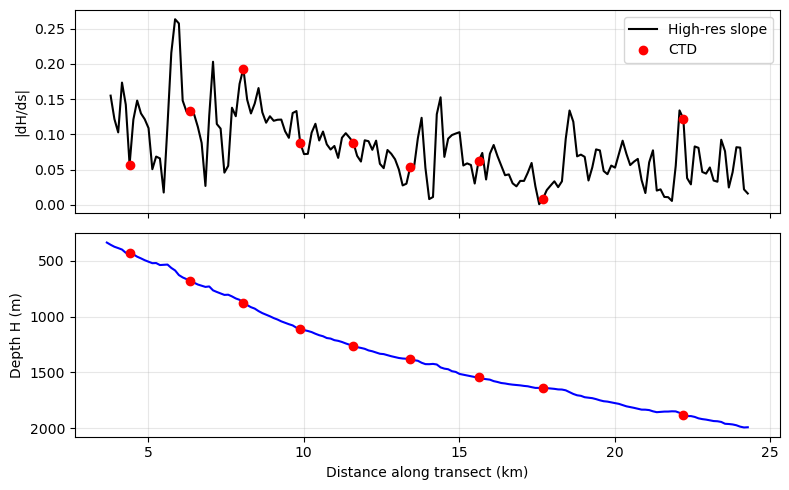

In [63]:
from scipy.interpolate import RegularGridInterpolator
import xarray as xr
import numpy as np
# Number of points along transect (increase for higher resolution)
n_transect = 200

lon_tr = np.linspace(line_lon.min(), line_lon.max(), n_transect)
lat_tr = np.interp(lon_tr, line_lon, line_lat)

lon_b = ds['lon'].values
lat_b = ds['lat'].values
elevation = ds['depth'].values   # negative in ocean


# Build interpolator
bathy_interp = RegularGridInterpolator(
    (lat_b, lon_b),          # GEBCO grid
    elevation,           # negative in ocean
    bounds_error=False,
    fill_value=np.nan
)

# Sample bathymetry along transect
H_tr = -bathy_interp(np.column_stack((lat_tr, lon_tr)))  # depth positive downward

# Earth radius
R = 6371e3

lat0 = np.deg2rad(np.mean(lat_tr))
lon0 = np.deg2rad(np.mean(lon_tr))

def ll_to_xy(lat, lon):
    lat = np.deg2rad(lat)
    lon = np.deg2rad(lon)
    x = R * (lon - lon0) * np.cos(lat0)
    y = R * (lat - lat0)
    return x, y

x_tr, y_tr = ll_to_xy(lat_tr, lon_tr)

# Distance along transect
s_tr = np.sqrt((x_tr - x_tr[0])**2 + (y_tr - y_tr[0])**2)


# Along-transect bottom slope
dH_ds = np.gradient(H_tr, s_tr)
slope_hr = np.abs(dH_ds)
# Station lon/lat
lon_sta = stations['lon'].values
lat_sta = stations['lat'].values

# Convert station positions to same x/y system
x_sta, y_sta = ll_to_xy(lat_sta, lon_sta)

# Compute distance along transect by nearest-point projection
stations['s_m'] = np.array([
    s_tr[np.argmin((x_tr - xs)**2 + (y_tr - ys)**2)]
    for xs, ys in zip(x_sta, y_sta)
])

stations['bottom_slope_hr'] = np.interp(
    stations['s_m'],
    s_tr,
    slope_hr
)

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 5),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 1]}
)

# --- Top panel: bottom slope ---
ax1.plot(s_tr / 1000, slope_hr, 'k-', label='High-res slope')
ax1.plot(
    stations['s_m'] / 1000,
    stations['bottom_slope_hr'],
    'ro',
    label='CTD'
)
ax1.set_ylabel('|dH/ds|')
ax1.legend()
ax1.grid(alpha=0.3)

# --- Bottom panel: bathymetry profile ---
ax2.plot(s_tr / 1000, H_tr, 'b-', lw=1.5)

# Optional: mark station locations on bathymetry
H_sta = np.interp(stations['s_m'], s_tr, H_tr)
ax2.plot(
    stations['s_m'] / 1000,
    H_sta,
    'ro'
)

ax2.set_xlabel('Distance along transect (km)')
ax2.set_ylabel('Depth H (m)')
ax2.grid(alpha=0.3)

# Optional: make depth increase downward
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [65]:
dx = np.median(np.diff(lon_b)) * deg2m_lon
dy = np.median(np.diff(lat_b)) * deg2m_lat

print(dx, dy)

NameError: name 'deg2m_lon' is not defined

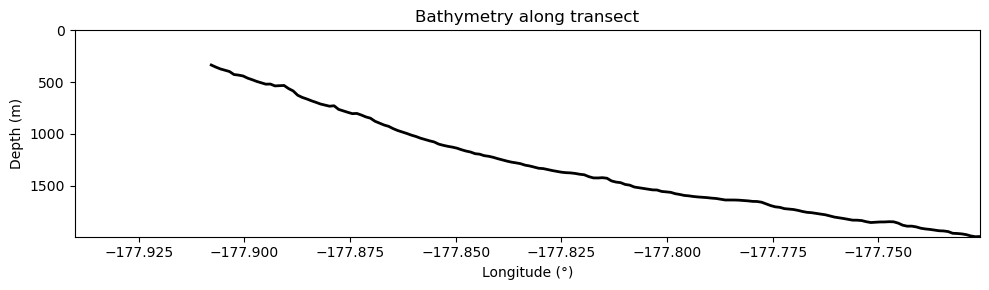

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# lon_tr : high‑resolution transect longitude
# H_tr   : bathymetry depth (positive downward)

fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(
    lon_tr,
    H_tr,
    color='k',
    linewidth=2
)

ax.set_ylim(np.nanmax(H_tr), 0)  # depth positive downward
ax.set_xlim(lon_tr.min(), lon_tr.max())

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Depth (m)')
ax.set_title('Bathymetry along transect')

plt.tight_layout()
plt.show()


In [68]:
import numpy as np

def slope_over_n_points(H, s, n=10):
    """
    Compute along-transect slope |dH/ds| using a running
    linear fit over n consecutive points.
    """
    slope = np.full_like(H, np.nan, dtype=float)
    half = n // 2

    for i in range(len(H)):
        i0 = max(0, i - half)
        i1 = min(len(H), i + half + 1)

        if i1 - i0 >= n:
            # Linear fit H = a*s + b
            coeffs = np.polyfit(s[i0:i1], H[i0:i1], 1)
            slope[i] = np.abs(coeffs[0])

    return slope


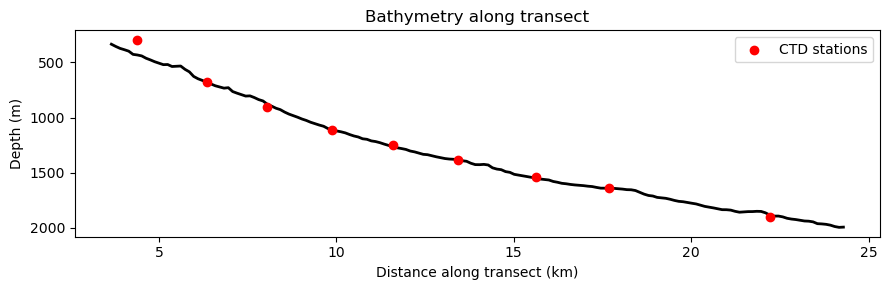

In [73]:
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# Build interpolator (same as before)
bathy_interp = RegularGridInterpolator(
    (lat_b, lon_b),
    ds.depth.values,
    bounds_error=False,
    fill_value=np.nan
)

# Sample bathymetry at station locations
stations['depth_bathy_m'] = -bathy_interp(
    np.column_stack((stations['lat'].values,
                     stations['lon'].values))
)
plt.figure(figsize=(9, 3))

plt.plot(
    s_tr / 1000,   # distance in km
    H_tr,
    'k',
    linewidth=2
)

# Shade below the bathymetry
plt.fill_between(
    s_tr / 1000,
    H_tr,
    H_tr.max() + 100,
    color='0.7'
)

# Overlay CTD station locations (optional, recommended)
plt.scatter(
    stations['s_m'] / 1000,
    stations['depth_bathy_m'],
    c='r',
    zorder=5,
    label='CTD stations'
)

plt.gca().invert_yaxis()
plt.xlabel('Distance along transect (km)')
plt.ylabel('Depth (m)')
plt.title('Bathymetry along transect')
plt.legend()

plt.tight_layout()
plt.show()


In [76]:
def comma_to_float(s):
    return pd.to_numeric(
        s.astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

numeric_cols = [
    'latitude_deg', 'longitude_deg', 'depth_m',
    'pressure_dbar', 'p_temperature_c',
    'p_salinity_psu',
    'p_sigma0_kgm3_minus_1000'
]

for c in numeric_cols:
    df[c] = comma_to_float(df[c])

stations_keep = [ 'TMB']  + [f'SE{i}' for i in range(1, 9)] 

df = df[df['station_label'].isin(stations_keep)].copy()

stations = (
    df.groupby('station_label')
      .agg(
          lat=('latitude_deg', 'mean'),
          lon=('longitude_deg', 'mean')
      )
      .reset_index()
)

R = 6371e3  # Earth radius [m]

lat0 = np.deg2rad(stations['lat'].mean())
lon0 = np.deg2rad(stations['lon'].mean())

def ll_to_xy(lat, lon):
    lat = np.deg2rad(lat)
    lon = np.deg2rad(lon)
    x = R * (lon - lon0) * np.cos(lat0)
    y = R * (lat - lat0)
    return x, y

stations['x'], stations['y'] = ll_to_xy(
    stations['lat'], stations['lon']
)


xy = stations[['x', 'y']].values
xy_mean = xy.mean(axis=0)
xyc = xy - xy_mean

U, S, Vt = np.linalg.svd(xyc)
transect_dir = Vt[0]   # unit vector along transect


df['x'], df['y'] = ll_to_xy(
    df['latitude_deg'], df['longitude_deg']
)

XY = np.column_stack((df['x'], df['y']))
df['s_m'] = (XY - xy_mean) @ transect_dir

g = 9.81
rho0 = 1025

df['rho'] = 1000 + df['p_sigma0_kgm3_minus_1000']
df['z'] = -df['depth_m']

Using 'station_str' as station identifier ✅


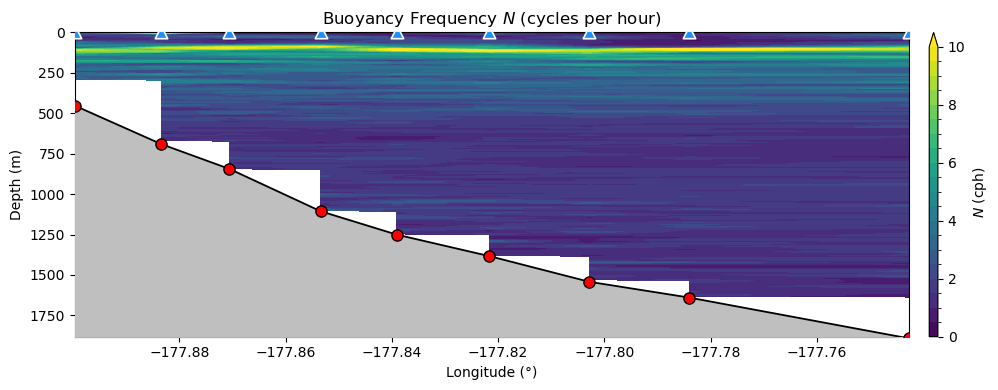

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ================================
# 1. Detect station column
# ================================
station_col = "station_str"   # confirmed from your output
print(f"Using '{station_col}' as station identifier ✅")

# ================================
# 2. Physical constants
# ================================
g = 9.81
rho0 = 1025.0

# ================================
# 3. Compute N² (depth positive down)
# ================================
df = df.copy()
df["N2"] = np.nan

for st in df[station_col].unique():
    prof = df[df[station_col] == st].sort_values("depth_m")
    if len(prof) < 3:
        continue

    depth = prof["depth_m"].values
    rho = prof["rho"].values
    drho_dz = np.gradient(rho, depth)

    df.loc[prof.index, "N2"] = (g / rho0) * drho_dz

# Remove unstable values (this prevents sqrt warnings)
df.loc[df["N2"] <= 0, "N2"] = np.nan

# ================================
# 4. Vertical smoothing (stronger)
# ================================
df["N2_smooth"] = np.nan

for st in df[station_col].unique():
    prof = df[df[station_col] == st].sort_values("depth_m")
    df.loc[prof.index, "N2_smooth"] = (
        prof["N2"]
        .rolling(window=10, center=True, min_periods=1)
        .mean()
    )

# ================================
# 5. Station‑based section grid
# ================================
stations = (
    df.groupby(station_col)
      .agg(lon=("longitude_deg", "mean"))
      .sort_values("lon")
      .reset_index()
)

x_grid = stations["lon"].values
nx = len(x_grid)

nz = 300
z_grid = np.linspace(0, df["depth_m"].max(), nz)

LON, DEPTH = np.meshgrid(x_grid, z_grid)

# ================================
# 6. Fill N² grid column‑by‑column
# ================================
N2_grid = np.full((nz, nx), np.nan)

for j, st in enumerate(stations[station_col]):
    prof = df[df[station_col] == st].sort_values("depth_m")

    if prof["N2_smooth"].notna().sum() < 3:
        continue

    fz = interp1d(
        prof["depth_m"],
        prof["N2_smooth"],
        bounds_error=False,
        fill_value=np.nan
    )

    N2_grid[:, j] = fz(z_grid)

# ================================
# 7. Convert to N (cycles per hour)
# ================================
N2_grid[N2_grid < 0] = np.nan   # safety
N_cph_grid = np.sqrt(N2_grid) * (3600 / (2 * np.pi))

# ================================
# 8. Bathymetry + masking
# ================================
H_sec = np.interp(x_grid, lon_tr, H_tr)

for j in range(nx):
    N_cph_grid[DEPTH[:, j] > H_sec[j], j] = np.nan

# ================================
# 9. Plot (final layout)
# ================================
fig, ax = plt.subplots(figsize=(11, 4))

levels = np.arange(0, 10.5, 0.5)

cf = ax.contourf(
    LON,
    DEPTH,
    N_cph_grid,
    levels=levels,
    cmap="viridis",
    extend="max"
)

# Bathymetry shading
ax.fill_between(
    x_grid,
    H_sec,
    DEPTH.max(),
    color="0.75",
    zorder=10
)

ax.plot(
    x_grid,
    H_sec,
    color="k",
    linewidth=1.3,
    zorder=11
)

# Blue triangles (CTD at surface)
ax.scatter(
    x_grid,
    np.zeros_like(x_grid),
    marker="^",
    s=80,
    facecolor="dodgerblue",
    edgecolor="white",
    linewidth=1.2,
    zorder=20,
    label="CTD"
)

# Red dots (bottom)
ax.scatter(
    x_grid,
    H_sec,
    marker="o",
    s=65,
    facecolor="red",
    edgecolor="k",
    zorder=21,
    label="Bottom"
)

ax.set_xlim(x_grid.min(), x_grid.max())
ax.set_ylim(DEPTH.max(), 0)

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Depth (m)")
ax.set_title("Buoyancy Frequency $N$ (cycles per hour)")

# Colorbar
cbar = fig.colorbar(
    cf,
    ax=ax,
    pad=0.02,
    aspect=35,
    ticks=np.arange(0, 10.1, 2)
)
cbar.set_label("$N$ (cph)")

cbar.ax.minorticks_on()

ax.legend(loc="lower left", frameon=True)

plt.tight_layout()
plt.show()

Using 'station_str' as station identifier ✅


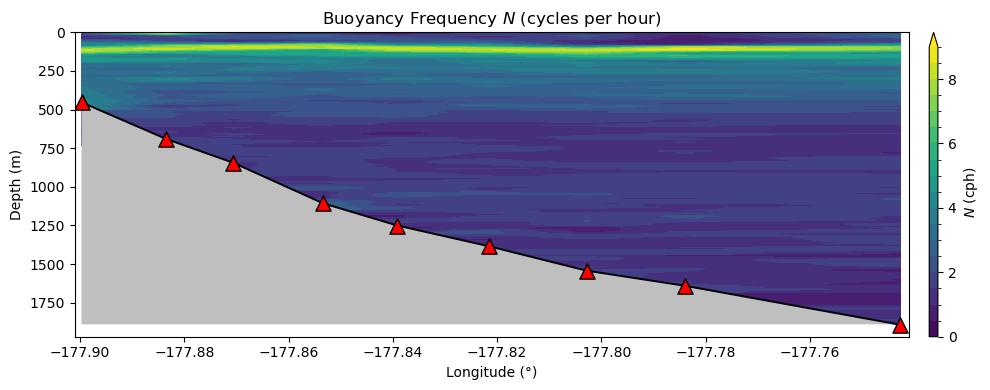

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# =====================================================
# ASSUMPTIONS (already exist in your workspace)
# =====================================================
# df      : CTD dataframe
# lon_tr  : 1D array of bathymetry longitudes
# H_tr    : 1D array of bathymetry depths (positive m)
#
# df columns used:
#   station_str, depth_m, longitude_deg, rho
# =====================================================

station_col = "station_str"
print(f"Using '{station_col}' as station identifier ✅")

# =====================================================
# 1. Physical constants
# =====================================================
g = 9.81
rho0 = 1025.0


# =====================================================
# 2. Compute N² (depth positive downward)
# =====================================================
df = df.copy()
df["N2"] = np.nan

for st in df[station_col].unique():
    prof = df[df[station_col] == st].sort_values("depth_m")
    if len(prof) < 3:
        continue

    depth = prof["depth_m"].values
    rho = prof["rho"].values

    drho_dz = np.gradient(rho, depth)
    df.loc[prof.index, "N2"] = (g / rho0) * drho_dz

# keep only stable stratification
df.loc[df["N2"] <= 0, "N2"] = np.nan


# =====================================================
# 3. Vertical smoothing (per station)
# =====================================================
df["N2_smooth"] = np.nan

for st in df[station_col].unique():
    prof = df[df[station_col] == st].sort_values("depth_m")
    df.loc[prof.index, "N2_smooth"] = (
        prof["N2"]
        .rolling(window=30, center=True, min_periods=1)
        .mean()
    )


# =====================================================
# 4. Build station‑based section grid
# =====================================================
stations = (
    df.groupby(station_col)
      .agg(lon=("longitude_deg", "mean"))
      .sort_values("lon")
      .reset_index()
)

x_grid = stations["lon"].values
nx = len(x_grid)

nz = 300
z_grid = np.linspace(0, df["depth_m"].max(), nz)

LON, DEPTH = np.meshgrid(x_grid, z_grid)


# =====================================================
# 5. Fill N² grid column‑by‑column
# =====================================================
N2_grid = np.full((nz, nx), np.nan)

for j, st in enumerate(stations[station_col]):
    prof = df[df[station_col] == st].sort_values("depth_m")
    if prof["N2_smooth"].notna().sum() < 3:
        continue

    fz = interp1d(
        prof["depth_m"],
        prof["N2_smooth"],
        bounds_error=False,
        fill_value='extrapolate'
    )

    N2_grid[:, j] = fz(z_grid)


# =====================================================
# 6. Convert to N (cycles per hour)
# =====================================================
N2_grid[N2_grid <= 0] = np.nan
N_cph_grid = np.sqrt(N2_grid) * (3600 / (2 * np.pi))


# =====================================================
# 7. Bathymetry and masking
# =====================================================
H_sec = np.interp(x_grid, lon_tr, H_tr)

for j in range(nx):
    N_cph_grid[DEPTH[:, j] > H_sec[j], j] = np.nan


# =====================================================
# 8. Fill white gaps (safe bottom extrapolation)
# =====================================================
extra_depth = 50.0  # meters

for j in range(nx):
    col = N_cph_grid[:, j]
    depth_col = DEPTH[:, j]

    valid = np.where(np.isfinite(col))[0]
    if valid.size == 0:
        continue

    last_idx = valid[-1]
    deepest_value = col[last_idx]
    deepest_depth = depth_col[last_idx]

    fill_mask = (
        (depth_col > deepest_depth) &
        (depth_col <= deepest_depth + extra_depth)
    )

    col[fill_mask] = deepest_value
    N_cph_grid[:, j] = col

# =====================================================
# Horizontal extrapolation to the LEFT (all columns)
# =====================================================
# For each column j, fill NaNs using column j+1

for j in range(N_cph_grid.shape[1] - 1):
    nan_mask = np.isnan(N_cph_grid[:, j])
    N_cph_grid[nan_mask, j] = N_cph_grid[nan_mask, j + 1]

# =====================================================
# 9. FINAL PLOT (matches your reference figure)
# =====================================================
fig, ax = plt.subplots(figsize=(11, 4))

levels = np.arange(0, 9.1, 0.5)

cf = ax.contourf(
    LON,
    DEPTH,
    N_cph_grid,
    levels=levels,
    cmap="viridis",
    extend="max"
)

# Bathymetry
ax.fill_between(
    x_grid,
    H_sec,
    DEPTH.max(),
    color="0.75",
    zorder=10
)

ax.plot(
    x_grid,
    H_sec,
    color="k",
    linewidth=1.4,
    zorder=11
)

# --------------------------------------------------
# Station positions and labels
# --------------------------------------------------

ax.scatter(
    x_grid,
    H_sec,
    marker="^",          # triangle
    s=120,
    color="red",
    edgecolor="k",
    linewidth=1,
    zorder=20
)


    


ax.set_xlim(x_grid.min(), x_grid.max())
ax.set_ylim(DEPTH.max(), 0)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Depth (m)")
ax.set_title("Buoyancy Frequency $N$ (cycles per hour)")

# Colorbar: labels every 2, minor ticks every 0.5
cbar = fig.colorbar(
    cf,
    ax=ax,
    pad=0.02,
    aspect=35,
    ticks=np.arange(0, 9.1, 2)
)
cbar.set_label("$N$ (cph)")
cbar.ax.minorticks_on()
plt.xlim(-177.901, -177.741)
plt.ylim(1970,0)
plt.tight_layout()
plt.show()

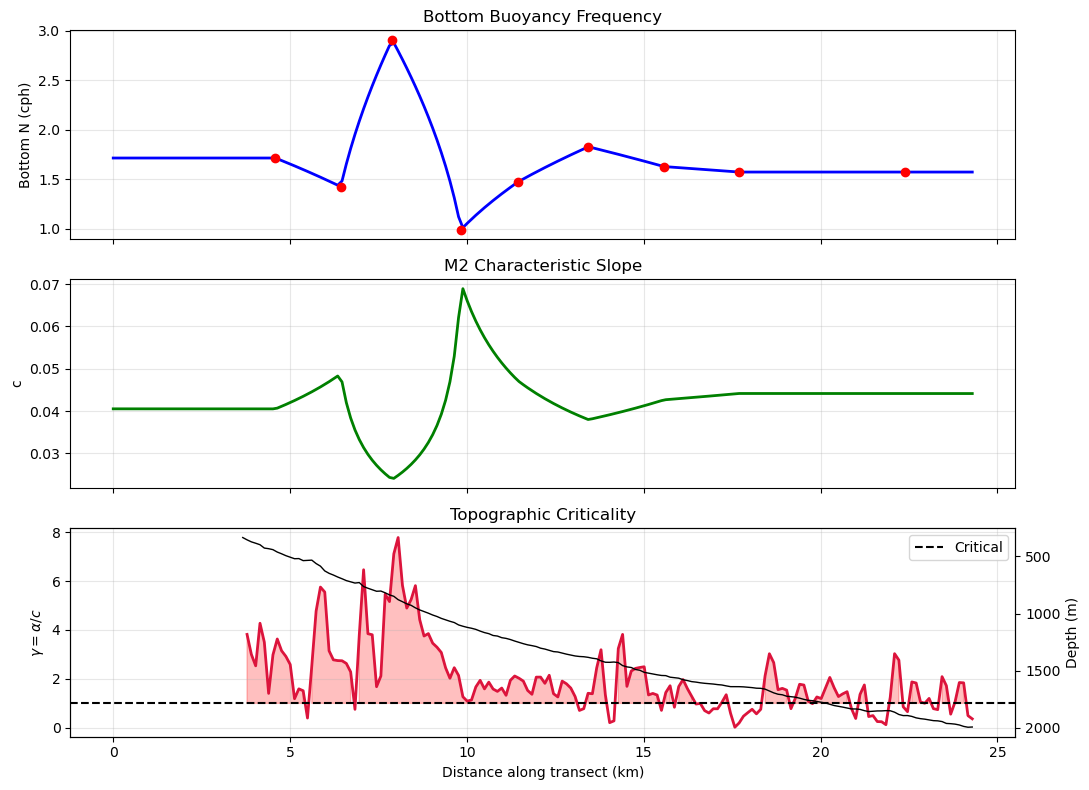

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# M2 frequency
# ==================================================
omega = 2 * np.pi / (12.42 * 3600)

# ==================================================
# Extract bottom N from section
# ==================================================
bottom_N_cph = np.full(nx, np.nan)

for j in range(nx):

    col = N_cph_grid[:, j]

    valid = np.where(np.isfinite(col))[0]

    if len(valid):
        bottom_N_cph[j] = col[valid[-1]]

# convert cph -> rad/s
bottom_N = bottom_N_cph * (2*np.pi / 3600)

# N² [s^-2]
bottom_N2 = bottom_N**2

# ==================================================
# Longitude -> transect distance
# ==================================================
s_grid = np.interp(
    x_grid,
    lon_tr,
    s_tr
)

# ==================================================
# Interpolate bottom N onto high-res transect
# ==================================================
N2_tr = np.interp(
    s_tr,
    s_grid,
    bottom_N2
)

N_tr = np.sqrt(N2_tr)

N_cph_tr = (
    N_tr * 3600/(2*np.pi)
)

# ==================================================
# Coriolis frequency
# ==================================================
Omega = 7.2921159e-5

f_tr = (
    2 * Omega *
    np.sin(np.deg2rad(lat_tr))
)

# ==================================================
# Bathymetric slope
# ==================================================
alpha_tr = np.abs(
    np.gradient(H_tr, s_tr)
)

# ==================================================
# Characteristic slope
# ==================================================
c_tr = np.full_like(s_tr, np.nan)

valid = (
    np.isfinite(N2_tr)
    & (N2_tr > omega**2)
    & (omega**2 > f_tr**2)
)

c_tr[valid] = np.sqrt(
    (omega**2 - f_tr[valid]**2)
    /
    (N2_tr[valid] - omega**2)
)

# ==================================================
# Criticality
# ==================================================
criticality_tr = alpha_tr / c_tr

criticality_tr[~np.isfinite(criticality_tr)] = np.nan

# ==================================================
# Plot
# ==================================================
fig, axes = plt.subplots(
    3,
    1,
    figsize=(11,8),
    sharex=True
)

# --------------------------------------------------
# Panel 1
# --------------------------------------------------
axes[0].plot(
    s_tr/1000,
    N_cph_tr,
    'b',
    lw=2
)

axes[0].plot(
    s_grid/1000,
    bottom_N_cph,
    'ro'
)

axes[0].set_ylabel('Bottom N (cph)')
axes[0].set_title('Bottom Buoyancy Frequency')
axes[0].grid(True, alpha=0.3)

# --------------------------------------------------
# Panel 2
# --------------------------------------------------
axes[1].plot(
    s_tr/1000,
    c_tr,
    color='green',
    lw=2
)

axes[1].set_ylabel('c')
axes[1].set_title('M2 Characteristic Slope')
axes[1].grid(True, alpha=0.3)

# --------------------------------------------------
# Panel 3
# --------------------------------------------------
axes[2].plot(
    s_tr/1000,
    criticality_tr,
    color='crimson',
    lw=2
)

axes[2].axhline(
    1,
    color='k',
    linestyle='--',
    label='Critical'
)

axes[2].fill_between(
    s_tr/1000,
    1,
    criticality_tr,
    where=criticality_tr > 1,
    color='red',
    alpha=0.25
)

axes[2].set_ylabel(r'$\gamma=\alpha/c$')
axes[2].set_xlabel('Distance along transect (km)')
axes[2].set_title('Topographic Criticality')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# --------------------------------------------------
# Bathymetry overlay
# --------------------------------------------------
axb = axes[2].twinx()



axb.plot(
    s_tr/1000,
    H_tr,
    'k',
    lw=1
)

axb.invert_yaxis()
axb.set_ylabel('Depth (m)')

plt.tight_layout()
plt.show()

N range (cph):
0.7415052456889465 3.009834595781718

c range:
0.023046000400495908 8.745452461876736


c:\Users\rkoe799\AppData\Local\anaconda3\envs\marine\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\rkoe799\AppData\Local\Temp\ipykernel_44060\2213286642.py:71: RuntimeWarning: invalid value encountered in sqrt
  N_tr = np.sqrt(N2_tr)
C:\Users\rkoe799\AppData\Local\Temp\ipykernel_44060\2213286642.py:102: RuntimeWarning: invalid value encountered in sqrt
  c_tr[valid] = np.sqrt(


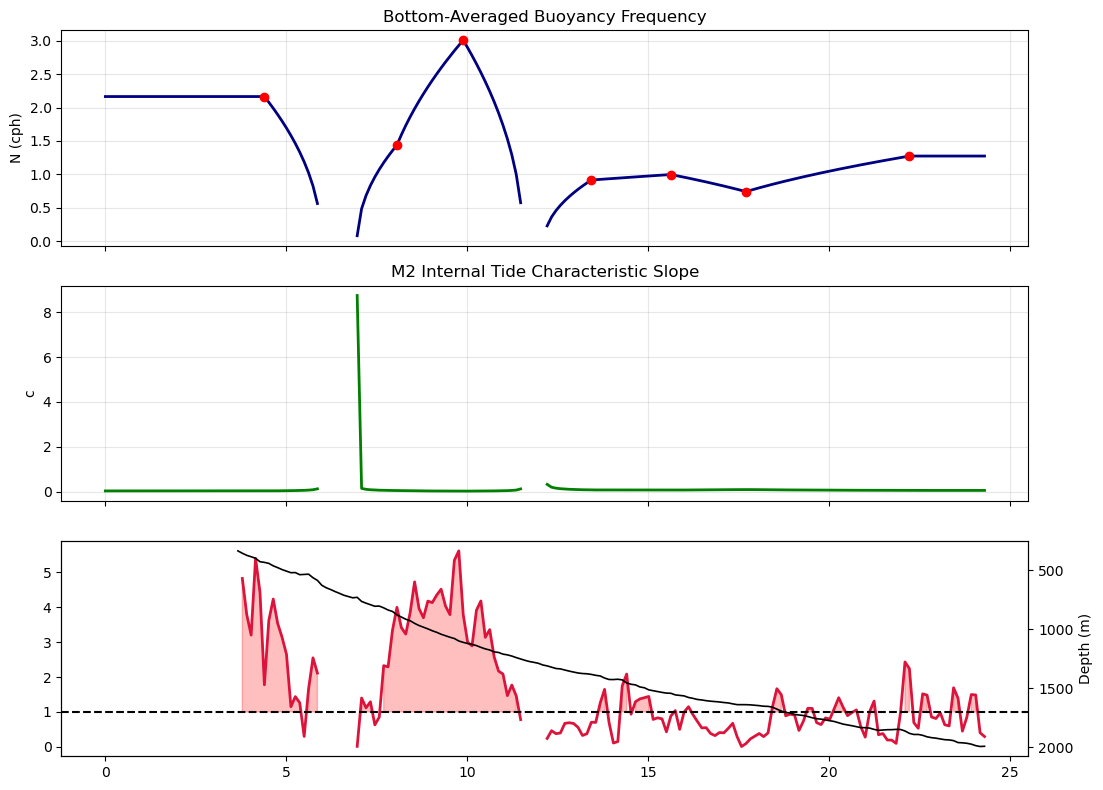

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Constants
# ==========================================================
omega = 2 * np.pi / (12.42 * 3600)      # M2 frequency [rad/s]
omega2 = omega**2

Omega = 7.2921159e-5                    # Earth rotation

# ==========================================================
# Build station table from CTD-derived bottom N²
# ==========================================================
station_N = (
    df.groupby('station_label')
      .agg(
          lon=('longitude_deg', 'mean'),
          lat=('latitude_deg', 'mean'),
          N2_bottom=('N2_bottom', 'first')
      )
      .reset_index()
)

station_N = station_N[
    np.isfinite(station_N['N2_bottom'])
].copy()

# ==========================================================
# Convert station positions to transect distance
# ==========================================================
x_sta, y_sta = ll_to_xy(
    station_N['lat'].values,
    station_N['lon'].values
)

station_N['s_m'] = np.array([
    s_tr[np.argmin((x_tr-xs)**2 + (y_tr-ys)**2)]
    for xs, ys in zip(x_sta, y_sta)
])

station_N = (
    station_N
    .sort_values('s_m')
    .drop_duplicates('s_m')
)

# ==========================================================
# Convert N² -> N
# ==========================================================
station_N['N_rad'] = np.sqrt(
    station_N['N2_bottom']
)

station_N['N_cph'] = (
    station_N['N_rad']
    * 3600 / (2*np.pi)
)

# ==========================================================
# Interpolate bottom N² onto full bathymetry transect
# (connect the CTD dots)
# ==========================================================
N2_tr = np.interp(
    s_tr,
    station_N['s_m'],
    station_N['N2_bottom']
)

N_tr = np.sqrt(N2_tr)

N_cph_tr = (
    N_tr * 3600 / (2*np.pi)
)

# ==========================================================
# Coriolis frequency
# ==========================================================
f_tr = (
    2 * Omega *
    np.sin(np.deg2rad(lat_tr))
)

# ==========================================================
# Bathymetric slope α
# ==========================================================
alpha_tr = np.abs(
    np.gradient(H_tr, s_tr)
)

# ==========================================================
# Internal-wave characteristic slope c
# ==========================================================
c_tr = np.full_like(s_tr, np.nan)

valid = (
    np.isfinite(N2_tr)

)

c_tr[valid] = np.sqrt(
    (omega2 - f_tr[valid]**2)
    /
    (N2_tr[valid] - omega2)
)

# ==========================================================
# Topographic criticality
# ==========================================================
criticality_tr = alpha_tr / c_tr

criticality_tr[~np.isfinite(criticality_tr)] = np.nan

# ==========================================================
# Diagnostics
# ==========================================================
print('N range (cph):')

print(
    np.nanmin(station_N['N_cph']),
    np.nanmax(station_N['N_cph'])
)

print('\nc range:')

print(
    np.nanmin(c_tr),
    np.nanmax(c_tr)
)

# ==========================================================
# Plot
# ==========================================================
fig, axes = plt.subplots(
    3,
    1,
    figsize=(11, 8),
    sharex=True
)

# ----------------------------------------------------------
# Panel 1: Bottom N
# ----------------------------------------------------------
axes[0].plot(
    s_tr / 1000,
    N_cph_tr,
    color='navy',
    lw=2
)

axes[0].scatter(
    station_N['s_m'] / 1000,
    station_N['N_cph'],
    color='red',
    zorder=10
)

axes[0].set_ylabel('N (cph)')
axes[0].set_title('Bottom-Averaged Buoyancy Frequency')
axes[0].grid(alpha=0.3)

# ----------------------------------------------------------
# Panel 2: Characteristic slope
# ----------------------------------------------------------
axes[1].plot(
    s_tr / 1000,
    c_tr,
    color='green',
    lw=2
)

axes[1].set_ylabel('c')
axes[1].set_title('M2 Internal Tide Characteristic Slope')
axes[1].grid(alpha=0.3)

# ----------------------------------------------------------
# Panel 3: Criticality
# ----------------------------------------------------------
axes[2].plot(
    s_tr / 1000,
    criticality_tr,
    color='crimson',
    lw=2
)

axes[2].axhline(
    1,
    color='k',
    linestyle='--',
    label='Critical'
)

axes[2].fill_between(
    s_tr / 1000,
    1,
    criticality_tr,
    where=(criticality_tr > 1),
    color='red',
    alpha=0.25
)



# ----------------------------------------------------------
# Bathymetry overlay
# ----------------------------------------------------------
axb = axes[2].twinx()



axb.plot(
    s_tr / 1000,
    H_tr,
    color='k',
    lw=1.2
)

axb.invert_yaxis()
axb.set_ylabel('Depth (m)')

plt.tight_layout()
plt.show()
        

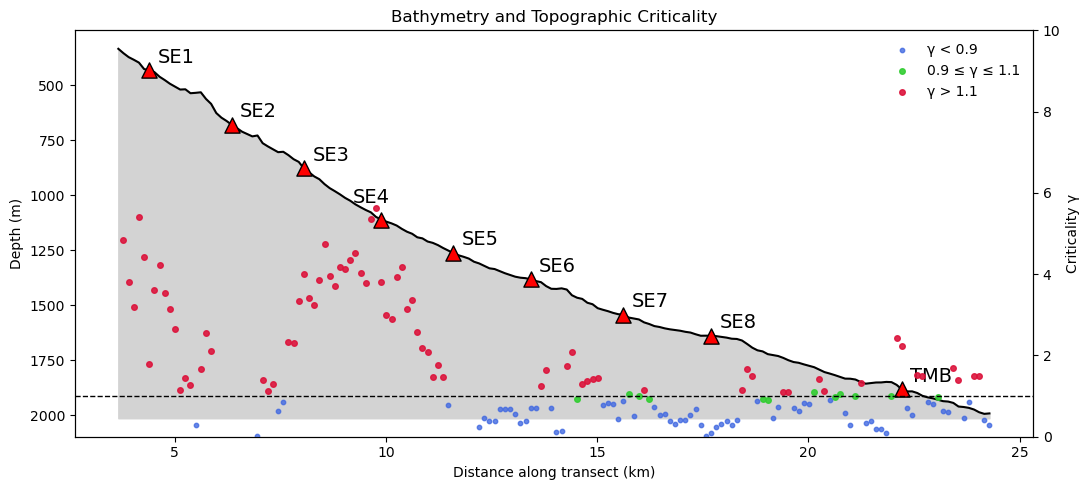

In [81]:
# ==========================================================
# Single bathymetry + criticality figure
# ==========================================================

fig, ax1 = plt.subplots(figsize=(11,5))

# ----------------------------------------------------------
# Bathymetry (left axis)
# ----------------------------------------------------------
ax1.fill_between(
    s_tr/1000,
    H_tr,
    np.nanmax(H_tr)+20,
    color='lightgray'
)

ax1.plot(
    s_tr/1000,
    H_tr,
    color='k',
    lw=1.5
)

ax1.invert_yaxis()
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel('Distance along transect (km)')

station_N = station_N[station_N['station_label'] != 'TMC']
# ----------------------------------------------------------
# Station locations on bathymetry
# ----------------------------------------------------------
station_N['depth'] = np.interp(
    station_N['s_m'],
    s_tr,
    H_tr
)

ax1.scatter(
    station_N['s_m']/1000,
    station_N['depth'],
    marker='^',
    s=120,
    color='red',
    edgecolor='k',
    zorder=10
)

for _, row in station_N.iterrows():

    x = row['s_m']/1000
    y = row['depth']
    label = row['station_label']

    # default
    dx = 0.20
    dy = -60
    ha = 'left'

    if label == 'SE4':
        dx = 0.2   # further left
        dy = -100       # lower on figure
        ha = 'right'

    elif label == 'TMA':
        dx = 0.25
        dy = -20

    ax1.text(
        x + dx,
        y + dy,
        label,
        fontsize=14,
        color='black',
        ha=ha,
        va='center'
    )
# ----------------------------------------------------------
# Criticality (right axis)
# ----------------------------------------------------------
ax2 = ax1.twinx()

near = (criticality_tr >= 0.9) & (criticality_tr <= 1.1)
sub  = criticality_tr < 0.9
super_ = criticality_tr > 1.1

ax2.scatter(
    s_tr[sub]/1000,
    criticality_tr[sub],
    color='royalblue',
    s=10,
    alpha=0.8,
    label='γ < 0.9'
)

ax2.scatter(
    s_tr[near]/1000,
    criticality_tr[near],
    color='limegreen',
    s=16,
    alpha=0.9,
    label='0.9 ≤ γ ≤ 1.1'
)

ax2.scatter(
    s_tr[super_]/1000,
    criticality_tr[super_],
    color='crimson',
    s=16,
    alpha=0.9,
    label='γ > 1.1'
)

ax2.axhline(
    1,
    color='k',
    ls='--',
    lw=1
)


ax2.set_ylabel('Criticality γ')
ax2.set_ylim(0, 10)

ax2.legend(
    loc='upper right',
    frameon=False
)

plt.title('Bathymetry and Topographic Criticality')
plt.tight_layout()
plt.show()

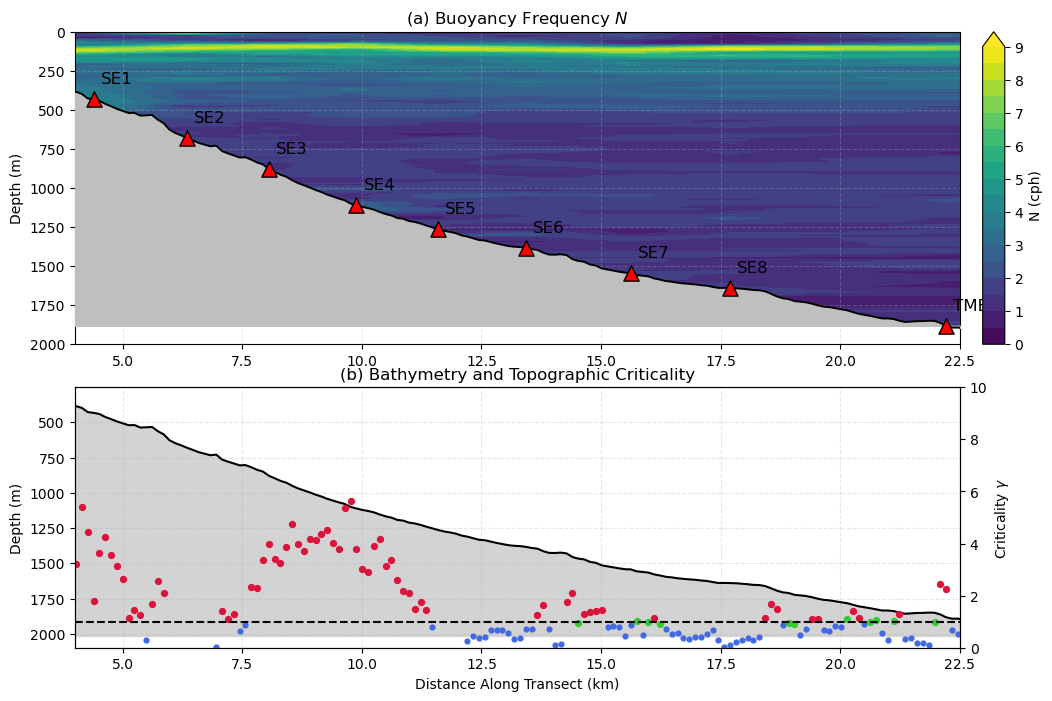

In [82]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# Interpolate N onto distance transect grid
# =====================================================

N_cph_grid_s = np.full((len(z_grid), len(s_tr)), np.nan)

station_s = station_N["s_m"].values

for k in range(len(z_grid)):

    row = N_cph_grid[k, :]
    good = np.isfinite(row)

    if np.sum(good) < 2:
        continue

    f = interp1d(
        station_s[good],
        row[good],
        bounds_error=False,
        fill_value='extrapolate'
    )

    N_cph_grid_s[k, :] = f(s_tr)

S_TR, DEPTH_TR = np.meshgrid(s_tr/1000, z_grid)

# =====================================================
# Figure layout
# =====================================================

fig = plt.figure(figsize=(12, 8))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[40, 1],
    height_ratios=[1.2, 1],
    hspace=0.15,
    wspace=0.05
)

ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0], sharex=ax_top)
cax    = fig.add_subplot(gs[0, 1])

# =====================================================
# TOP PANEL : N
# =====================================================

levels = np.arange(0, 9.5, 0.5)

cf = ax_top.contourf(
    S_TR,
    DEPTH_TR,
    N_cph_grid_s,
    levels=levels,
    cmap='viridis',
    extend='max'
)

ax_top.fill_between(
    s_tr/1000,
    H_tr,
    DEPTH_TR.max(),
    color='0.75',
    zorder=10
)

ax_top.plot(
    s_tr/1000,
    H_tr,
    color='k',
    lw=1.4,
    zorder=11
)

# station markers

station_N_plot = station_N[
    station_N['station_label'] != 'TMC'
].copy()

station_N_plot['depth'] = np.interp(
    station_N_plot['s_m'],
    s_tr,
    H_tr
)

ax_top.scatter(
    station_N_plot['s_m']/1000,
    station_N_plot['depth'],
    marker='^',
    s=120,
    color='red',
    edgecolor='k',
    zorder=20
)

for _, row in station_N_plot.iterrows():

    ax_top.text(
        row['s_m']/1000 + 0.15,
        row['depth'] - 100,
        row['station_label'],
        fontsize=12,
        zorder=30
    )

ax_top.set_ylim(2000, 0)
ax_top.set_ylabel('Depth (m)')
ax_top.set_title('(a) Buoyancy Frequency $N$')

ax_top.grid(
    True,
    linestyle='--',
    alpha=0.3
)

cbar = fig.colorbar(cf, cax=cax)
cbar.set_label('N (cph)')

# =====================================================
# BOTTOM PANEL : Bathymetry + Criticality
# =====================================================

ax_bot.fill_between(
    s_tr/1000,
    H_tr,
    np.nanmax(H_tr)+20,
    color='lightgray'
)

ax_bot.plot(
    s_tr/1000,
    H_tr,
    color='k',
    lw=1.5
)

ax_bot.invert_yaxis()

ax_bot.set_ylabel('Depth (m)')
ax_bot.set_xlabel('Distance Along Transect (km)')

ax_bot.grid(
    True,
    linestyle='--',
    alpha=0.3
)

# -----------------------------------------------------
# Criticality
# -----------------------------------------------------

ax_cr = ax_bot.twinx()

near = (criticality_tr >= 0.9) & (criticality_tr <= 1.1)
sub  = criticality_tr < 0.9
sup  = criticality_tr > 1.1

ax_cr.scatter(
    s_tr[sub]/1000,
    criticality_tr[sub],
    color='royalblue',
    s=12
)

ax_cr.scatter(
    s_tr[near]/1000,
    criticality_tr[near],
    color='limegreen',
    s=18
)

ax_cr.scatter(
    s_tr[sup]/1000,
    criticality_tr[sup],
    color='crimson',
    s=18
)

ax_cr.axhline(
    1,
    color='k',
    ls='--'
)

ax_cr.set_ylabel(r'Criticality $\gamma$')
ax_cr.set_ylim(0, 10)
ax_cr.set_xlim(4,22.5)

ax_bot.set_title('(b) Bathymetry and Topographic Criticality')

plt.show()

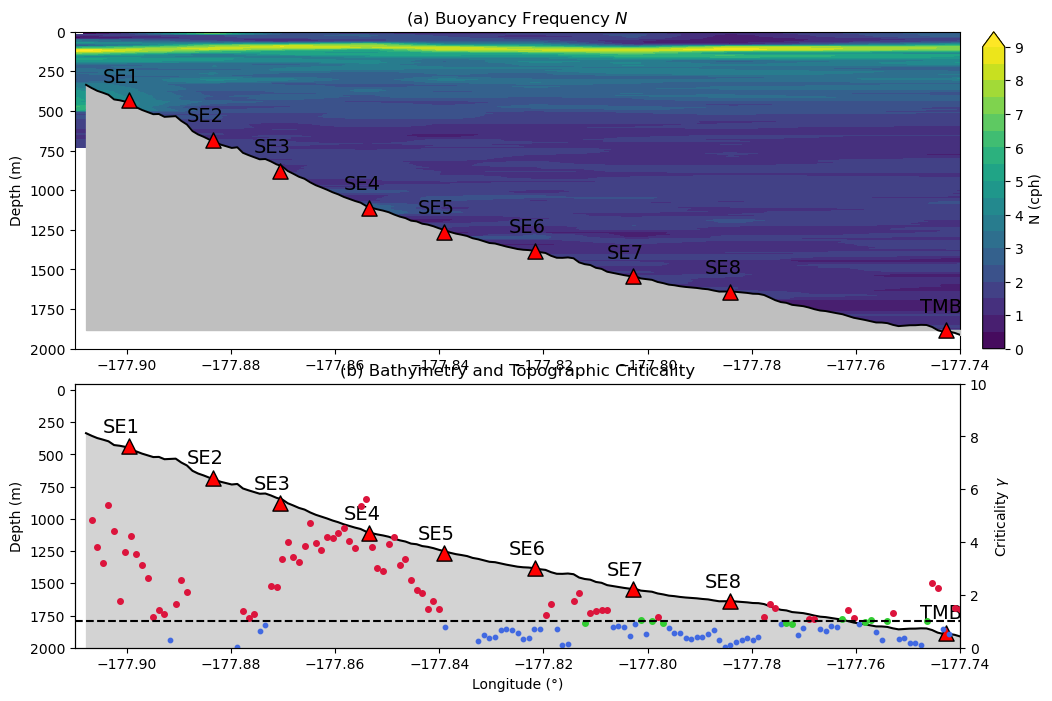

In [83]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# Interpolate N onto lon_tr
# =====================================================

N_cph_grid_lon = np.full((len(z_grid), len(lon_tr)), np.nan)

for k in range(len(z_grid)):

    row = N_cph_grid[k, :]
    good = np.isfinite(row)

    if np.sum(good) < 2:
        continue

    f = interp1d(
        x_grid,
        row,
        bounds_error=False,
        fill_value='extrapolate'
    )

    N_cph_grid_lon[k, :] = f(lon_tr)

LON_TR, DEPTH_TR = np.meshgrid(lon_tr, z_grid)

# =====================================================
# Station longitudes
# =====================================================

plot_stations = station_N[
    station_N['station_label'] != 'TMC'
].copy()

plot_stations['depth'] = np.interp(
    plot_stations['s_m'],
    s_tr,
    H_tr
)

station_lon = (
    df.groupby('station_label')['longitude_deg']
      .mean()
)

plot_stations['lon'] = (
    plot_stations['station_label']
    .map(station_lon)
)

# =====================================================
# Figure (manual colorbar axis)
# =====================================================

fig = plt.figure(figsize=(12,8))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[40,1],
    height_ratios=[1.2,1],
    hspace=0.12,
    wspace=0.05
)

ax_top = fig.add_subplot(gs[0,0])
ax_bot = fig.add_subplot(gs[1,0], sharex=ax_top)
cax    = fig.add_subplot(gs[0,1])

# =====================================================
# TOP PANEL
# =====================================================

levels = np.arange(0, 9.1, 0.5)

cf = ax_top.contourf(
    LON_TR,
    DEPTH_TR,
    N_cph_grid_lon,
    levels=levels,
    cmap='viridis',
    extend='max'
)

ax_top.fill_between(
    lon_tr,
    H_tr,
    DEPTH_TR.max(),
    color='0.75',
    zorder=10
)

ax_top.plot(
    lon_tr,
    H_tr,
    color='k',
    lw=1.4,
    zorder=11
)

# same triangles
ax_top.scatter(
    plot_stations['lon'],
    plot_stations['depth'],
    marker='^',
    s=120,
    color='red',
    edgecolor='k',
    zorder=20
)

# same labels
for _, row in plot_stations.iterrows():

    x = row['lon']
    y = row['depth']
    label = row['station_label']

    dx = -0.005
    dy = -150
    ha = 'left'



    ax_top.text(
        x + dx,
        y + dy,
        label,
        fontsize=14,
        color='black',
        ha=ha,
        va='center',
        zorder=30
    )

ax_top.set_ylim(2000,0)
ax_top.set_ylabel('Depth (m)')
ax_top.set_title('(a) Buoyancy Frequency $N$')

# dedicated colorbar axis
cbar = fig.colorbar(cf, cax=cax)
cbar.set_label('N (cph)')

# =====================================================
# BOTTOM PANEL
# =====================================================

ax_bot.fill_between(
    lon_tr,
    H_tr,
    np.nanmax(H_tr)+20,
    color='lightgray'
)

ax_bot.plot(
    lon_tr,
    H_tr,
    color='k',
    lw=1.5
)

ax_bot.invert_yaxis()

ax_bot.scatter(
    plot_stations['lon'],
    plot_stations['depth'],
    marker='^',
    s=120,
    color='red',
    edgecolor='k',
    zorder=20
)

for _, row in plot_stations.iterrows():

    x = row['lon']
    y = row['depth']
    label = row['station_label']

    dx = -0.005
    dy = -150
    ha = 'left'

   
    ax_bot.text(
        x + dx,
        y + dy,
        label,
        fontsize=14,
        color='black',
        ha=ha,
        va='center',
        zorder=30
    )

# =====================================================
# Criticality
# =====================================================

ax_cr = ax_bot.twinx()

near = (criticality_tr >= 0.9) & (criticality_tr <= 1.1)
sub  = criticality_tr < 0.9
sup  = criticality_tr > 1.1

ax_cr.scatter(
    lon_tr[sub],
    criticality_tr[sub],
    color='royalblue',
    s=10
)

ax_cr.scatter(
    lon_tr[near],
    criticality_tr[near],
    color='limegreen',
    s=16
)

ax_cr.scatter(
    lon_tr[sup],
    criticality_tr[sup],
    color='crimson',
    s=16
)

ax_cr.axhline(
    1,
    color='k',
    ls='--'
)

ax_cr.set_ylabel(r'Criticality $\gamma$')
ax_cr.set_ylim(0,10)

# =====================================================
# IDENTICAL X AXIS FOR BOTH PANELS
# =====================================================

xmin = -177.91
xmax = -177.74

ax_top.set_xlim(xmin, xmax)
ax_bot.set_xlim(xmin, xmax)
ax_bot.set_ylim(2000, -50)

ax_bot.set_xlabel('Longitude (°)')
ax_bot.set_ylabel('Depth (m)')
ax_bot.set_title('(b) Bathymetry and Topographic Criticality')

plt.show()

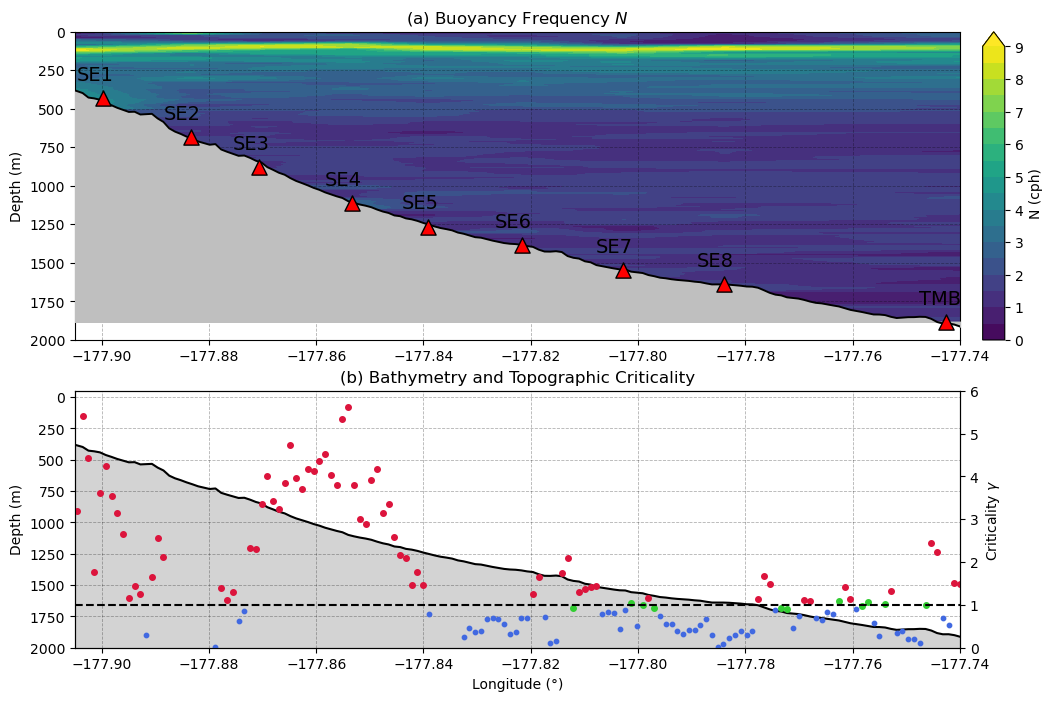

In [84]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# Interpolate N onto lon_tr (WITH EXTRAPOLATION)
# =====================================================

N_cph_grid_lon = np.full((len(z_grid), len(lon_tr)), np.nan)

for k in range(len(z_grid)):

    row = N_cph_grid[k, :]
    good = np.isfinite(row)

    if np.sum(good) < 2:
        continue

    f = interp1d(
        x_grid[good],
        row[good],
        bounds_error=False,
        fill_value='extrapolate'
    )

    N_cph_grid_lon[k, :] = f(lon_tr)

LON_TR, DEPTH_TR = np.meshgrid(lon_tr, z_grid)

# =====================================================
# Station longitudes
# =====================================================

plot_stations = station_N[
    station_N['station_label'] != 'TMC'
].copy()

plot_stations['depth'] = np.interp(
    plot_stations['s_m'],
    s_tr,
    H_tr
)

station_lon = (
    df.groupby('station_label')['longitude_deg']
      .mean()
)

plot_stations['lon'] = (
    plot_stations['station_label']
    .map(station_lon)
)

# =====================================================
# Figure
# =====================================================

fig = plt.figure(figsize=(12, 8))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[40, 1],
    height_ratios=[1.2, 1],
    hspace=0.18,      # more separation
    wspace=0.05
)

ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0], sharex=ax_top)
cax    = fig.add_subplot(gs[0, 1])

# =====================================================
# TOP PANEL: N
# =====================================================

levels = np.arange(0, 9.1, 0.5)

cf = ax_top.contourf(
    LON_TR,
    DEPTH_TR,
    N_cph_grid_lon,
    levels=levels,
    cmap='viridis',
    extend='max'
)

ax_top.fill_between(
    lon_tr,
    H_tr,
    DEPTH_TR.max(),
    color='0.75',
    zorder=10
)

ax_top.plot(
    lon_tr,
    H_tr,
    color='k',
    lw=1.4,
    zorder=11
)

# Station markers ONLY in top panel
ax_top.scatter(
    plot_stations['lon'],
    plot_stations['depth'],
    marker='^',
    s=120,
    color='red',
    edgecolor='k',
    zorder=20
)

for _, row in plot_stations.iterrows():

    x = row['lon']
    y = row['depth']
    label = row['station_label']

    ax_top.text(
        x - 0.005,
        y - 150,
        label,
        fontsize=14,
        color='black',
        ha='left',
        va='center',
        zorder=30
    )

ax_top.set_ylim(2000, 0)
ax_top.set_ylabel('Depth (m)')
ax_top.set_title('(a) Buoyancy Frequency $N$')

# Grid lines
ax_top.grid(
    True,
    linestyle='--',
    linewidth=0.6,
    color='k',
    alpha=0.3,
    zorder=35
)

# Colorbar
cbar = fig.colorbar(cf, cax=cax)
cbar.set_label('N (cph)')

# =====================================================
# BOTTOM PANEL: Bathymetry
# =====================================================

ax_bot.fill_between(
    lon_tr,
    H_tr,
    np.nanmax(H_tr) + 20,
    color='lightgray'
)

ax_bot.plot(
    lon_tr,
    H_tr,
    color='k',
    lw=1.5
)

ax_bot.invert_yaxis()

# No station triangles
# No station labels

# Grid lines
ax_bot.grid(
    True,
    linestyle='--',
    linewidth=0.6,
    color='k',
    alpha=0.3
)

# =====================================================
# Criticality
# =====================================================

ax_cr = ax_bot.twinx()

near = (criticality_tr >= 0.9) & (criticality_tr <= 1.1)
sub  = criticality_tr < 0.9
sup  = criticality_tr > 1.1

ax_cr.scatter(
    lon_tr[sub],
    criticality_tr[sub],
    color='royalblue',
    s=10
)

ax_cr.scatter(
    lon_tr[near],
    criticality_tr[near],
    color='limegreen',
    s=16
)

ax_cr.scatter(
    lon_tr[sup],
    criticality_tr[sup],
    color='crimson',
    s=16
)

ax_cr.axhline(
    1,
    color='k',
    ls='--'
)

ax_cr.set_ylabel(r'Criticality $\gamma$')
ax_cr.set_ylim(0, 6)

# =====================================================
# Axes
# =====================================================

xmin = -177.905

xmax = -177.74

ax_top.set_xlim(xmin, xmax)
ax_bot.set_xlim(xmin, xmax)

ax_bot.set_ylim(2000, -50)

ax_bot.set_xlabel('Longitude (°)')
ax_bot.set_ylabel('Depth (m)')
ax_bot.set_title('(b) Bathymetry and Topographic Criticality')

plt.show()


  station_label         lon        depth
0           SE1 -177.899678   432.608068
1           SE2 -177.883416   680.442721
2           SE3 -177.870582   878.704992
3           SE4 -177.853406  1111.090127
4           SE5 -177.839114  1263.743125
5           SE6 -177.821657  1382.991540
6           SE7 -177.802825  1543.112818
7           SE8 -177.784073  1639.781621
8           TMB -177.742661  1883.112917


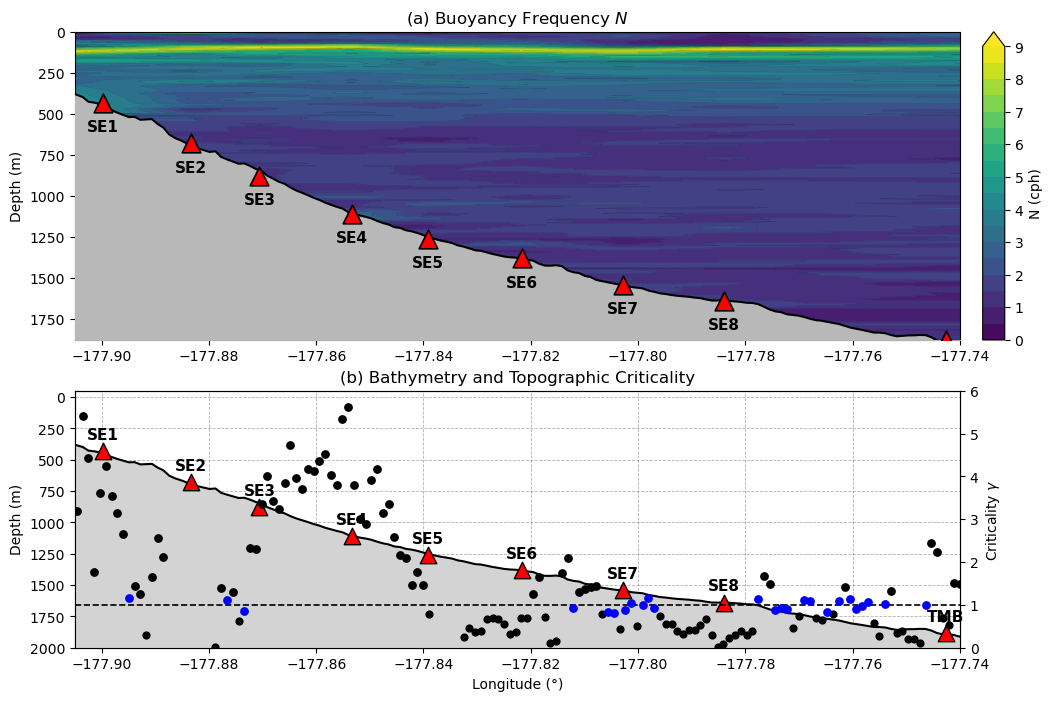

In [85]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# Interpolate N onto lon_tr (WITH EXTRAPOLATION)
# =====================================================

N_cph_grid_lon = np.full((len(z_grid), len(lon_tr)), np.nan)

for k in range(len(z_grid)):

    row = N_cph_grid[k, :]
    good = np.isfinite(row)

    if np.sum(good) < 2:
        continue

    f = interp1d(
        x_grid[good],
        row[good],
        bounds_error=False,
        fill_value='extrapolate'
    )

    N_cph_grid_lon[k, :] = f(lon_tr)

LON_TR, DEPTH_TR = np.meshgrid(lon_tr, z_grid)

# =====================================================
# Station longitudes
# =====================================================

plot_stations = station_N[
    station_N['station_label'] != 'TMC'
].copy()

plot_stations['depth'] = np.interp(
    plot_stations['s_m'],
    s_tr,
    H_tr
)

station_lon = (
    df.groupby('station_label')['longitude_deg']
      .mean()
)
print(plot_stations[['station_label', 'lon', 'depth']])


plot_stations['lon'] = (
    plot_stations['station_label']
    .map(station_lon)
)

# =====================================================
# Figure
# =====================================================

fig = plt.figure(figsize=(12, 8))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[40, 1],
    height_ratios=[1.2, 1],
    hspace=0.18,      # more separation
    wspace=0.05
)

ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0], sharex=ax_top)
cax    = fig.add_subplot(gs[0, 1])
# =====================================================
# TOP PANEL: N
# =====================================================
# =====================================================
# TOP PANEL: N
# =====================================================

levels = np.arange(0, 9.1, 0.5)

cf = ax_top.contourf(
    LON_TR,
    DEPTH_TR,
    N_cph_grid_lon,
    levels=levels,
    cmap='viridis',
    extend='max'
)

# Light contour lines instead of grid
ax_top.contour(
    LON_TR,
    DEPTH_TR,
    N_cph_grid_lon,
    levels=levels,
    colors='k',
    linewidths=0.25,
    alpha=0.25
)

# Bathymetry
ax_top.fill_between(
    lon_tr,
    H_tr,
    DEPTH_TR.max(),
    color='0.72',
    zorder=20
)

ax_top.plot(
    lon_tr,
    H_tr,
    color='k',
    lw=1.5,
    zorder=21
)

# Remove stations that have NaN coordinates
plot_stations_plot = plot_stations.dropna(
    subset=['lon', 'depth']
)

# Triangles
ax_top.scatter(
    plot_stations_plot['lon'],
    plot_stations_plot['depth'],
    marker='^',
    s=180,
    c='red',
    edgecolors='k',
    linewidths=1.2,
    zorder=50
)

# Labels
for _, row in plot_stations_plot.iterrows():

    ax_top.annotate(
        row['station_label'],
        (row['lon'], row['depth']),
        xytext=(0, -12),
        textcoords='offset points',
        ha='center',
        va='top',
        fontsize=11,
        fontweight='bold',
        color='k',
        zorder=60
    )

ax_top.set_ylim(1880, 0)
ax_top.set_ylabel('Depth (m)')
ax_top.set_title(r'(a) Buoyancy Frequency $N$')

cbar = fig.colorbar(cf, cax=cax)
cbar.set_label('N (cph)')

# =====================================================
# BOTTOM PANEL: Bathymetry
# =====================================================

ax_bot.fill_between(
    lon_tr,
    H_tr,
    np.nanmax(H_tr) + 20,
    color='lightgray',
    zorder=10
)

ax_bot.plot(
    lon_tr,
    H_tr,
    color='k',
    lw=1.5,
    zorder=11
)

# Station triangles
ax_bot.scatter(
    plot_stations['lon'],
    plot_stations['depth'],
    marker='^',
    s=140,
    facecolor='red',
    edgecolor='k',
    linewidth=1.0,
    zorder=30
)

# Station labels
for _, row in plot_stations.iterrows():

    ax_bot.text(
        row['lon'],
        row['depth'] - 70,
        row['station_label'],
        fontsize=11,
        fontweight='bold',
        color='k',
        ha='center',
        va='bottom',
        zorder=40
    )

ax_bot.grid(
    True,
     linestyle='--',
    linewidth=0.6,
    color='k',
    alpha=0.3
)

ax_bot.invert_yaxis()

# =====================================================
# Criticality
# =====================================================

ax_cr = ax_bot.twinx()

near = (criticality_tr >= 0.8) & (criticality_tr <= 1.2)
sub  = criticality_tr < 0.8
sup  = criticality_tr > 1.2

# Black dots everywhere
ax_cr.scatter(
    lon_tr,
    criticality_tr,
    color='k',
    s=8,
    alpha=0.5,
    zorder=1
)

# Black subcritical
ax_cr.scatter(
    lon_tr[sub],
    criticality_tr[sub],
    color='black',
    s=24,
    zorder=5
)

# Blue near-critical
ax_cr.scatter(
    lon_tr[near],
    criticality_tr[near],
    color='blue',
    s=28,
    zorder=6
)

# Black supercritical
ax_cr.scatter(
    lon_tr[sup],
    criticality_tr[sup],
    color='black',
    s=28,
    zorder=5
)

ax_cr.axhline(
    1,
    color='k',
    ls='--',
    lw=1.2
)

ax_cr.set_ylabel(r'Criticality $\gamma$')
ax_cr.set_ylim(0, 6)

# =====================================================
# Axes
# =====================================================

xmin = -177.905
xmax = -177.74

ax_top.set_xlim(xmin, xmax)
ax_bot.set_xlim(xmin, xmax)

ax_top.set_ylim(1880, 0)
ax_bot.set_ylim(2000, -50)

ax_bot.set_xlabel('Longitude (°)')
ax_bot.set_ylabel('Depth (m)')
ax_bot.set_title('(b) Bathymetry and Topographic Criticality')

plt.show()

Original grid: 200
Extended grid: 200
Original xmax: -177.72597254426034
Extended xmax: -177.7259725442618


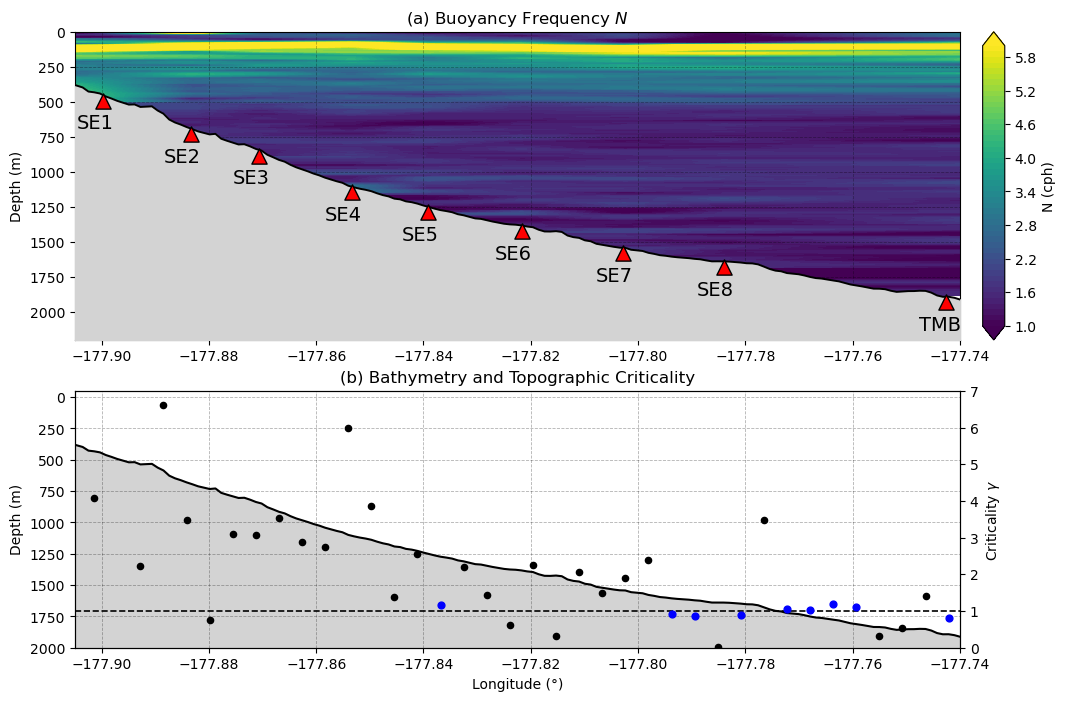

In [88]:
from scipy.interpolate import interp1d
import numpy as np

# =====================================================
# EXTEND LONGITUDE GRID EASTWARD
# =====================================================

dlon = np.median(np.diff(lon_tr))

lon_tr_ext = np.arange(
    lon_tr.min(),
    lon_tr.max() + 0.00005,
    dlon
)

# =====================================================
# EXTEND BATHYMETRY
# =====================================================

fH = interp1d(
    lon_tr,
    H_tr,
    bounds_error=False,
    fill_value="extrapolate"
)

H_tr_ext = fH(lon_tr_ext)

# =====================================================
# INTERPOLATE N ONTO EXTENDED LONGITUDE GRID
# =====================================================

N_cph_grid_lon = np.full(
    (len(z_grid), len(lon_tr_ext)),
    np.nan
)

for k in range(len(z_grid)):

    row = N_cph_grid[k, :]
    good = np.isfinite(row)

    if np.sum(good) < 2:
        continue

    fN = interp1d(
        x_grid[good],
        row[good],
        bounds_error=False,
        fill_value="extrapolate"
    )

    N_cph_grid_lon[k, :] = fN(lon_tr_ext)

# =====================================================
# FILL TO SEABED (+50 m BUFFER)
# Extend deepest valid N downward
# =====================================================

for i, H in enumerate(H_tr_ext):

    prof = N_cph_grid_lon[:, i]

    good = np.where(np.isfinite(prof))[0]

    if len(good) == 0:
        continue

    last_idx = good[-1]

    # fill ALL NaNs below deepest valid point
    prof[last_idx:] = prof[last_idx]

    N_cph_grid_lon[:, i] = prof

# =====================================================
# MESHGRID FOR PLOTTING
# =====================================================

LON_TR, DEPTH_TR = np.meshgrid(
    lon_tr_ext,
    z_grid
)

# =====================================================
# CRITICALITY
# =====================================================

lat0 = np.nanmean(lat_tr)

x_m = (
    (lon_tr_ext - lon_tr_ext[0])
    * 111320
    * np.cos(np.deg2rad(lat0))
)

bathy_slope = np.abs(
    np.gradient(H_tr_ext, x_m)
)

# =====================================================
# BOTTOM N (BOTTOM 5 m)
# =====================================================

N_bottom = np.full(
    len(lon_tr_ext),
    np.nan
)

for i, H in enumerate(H_tr_ext):

    mask = (
        (z_grid >= max(0, H - 5))
        & (z_grid <= H)
    )

    vals = N_cph_grid_lon[mask, i]

    if np.any(np.isfinite(vals)):
        N_bottom[i] = np.nanmean(vals)

# =====================================================
# FILL GAPS IN BOTTOM N
# =====================================================

good = np.isfinite(N_bottom)

if np.sum(good) > 2:

    fNbot = interp1d(
        lon_tr_ext[good],
        N_bottom[good],
        bounds_error=False,
        fill_value="extrapolate"
    )

    N_bottom = fNbot(lon_tr_ext)

# =====================================================
# M2 CRITICALITY
# =====================================================

omega = 1.405e-4

f_cor = (
    2
    * 7.292115e-5
    * np.sin(np.deg2rad(lat0))
)

N_rad = N_bottom * (2 * np.pi / 3600)

ray_slope = np.full_like(
    N_rad,
    np.nan
)

good = (
    np.isfinite(N_rad)
    & (N_rad > omega)
)

ray_slope[good] = np.sqrt(
    (omega**2 - f_cor**2)
    / (N_rad[good]**2 - omega**2)
)

criticality_tr = bathy_slope / ray_slope

criticality_tr[~np.isfinite(criticality_tr)] = np.nan


step = 4

lon_plot = lon_tr_ext[::step]
crit_plot = criticality_tr[::step]

# =====================================================
# STATIONS
# =====================================================

plot_stations = station_N[
    station_N['station_label'] != 'TMC'
].copy()

station_lon = (
    df.groupby('station_label')['longitude_deg']
      .mean()
)

plot_stations['lon'] = (
    plot_stations['station_label']
    .map(station_lon)
)

plot_stations['depth'] = np.interp(
    plot_stations['lon'],
    lon_tr_ext,
    H_tr_ext
)



print("Original grid:", len(lon_tr))
print("Extended grid:", len(lon_tr_ext))
print("Original xmax:", lon_tr.max())
print("Extended xmax:", lon_tr_ext.max())


# =====================================================
# Figure
# =====================================================

fig = plt.figure(figsize=(12, 8))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[40, 1],
    height_ratios=[1.2, 1],
    hspace=0.18,
    wspace=0.05
)

ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0], sharex=ax_top)
cax = fig.add_subplot(gs[0, 1])

# =====================================================
# TOP PANEL: N
# =====================================================

cf = ax_top.contourf(
    LON_TR,
    DEPTH_TR,
    N_cph_grid_lon,
    levels=np.arange(1, 6.1, 0.1),
    cmap='viridis',
    extend='both'
)

ax_top.fill_between(
    lon_tr_ext,
    H_tr_ext,
    2200,
    color='lightgrey',
    zorder=10
)

ax_top.plot(
    lon_tr_ext,
    H_tr_ext,
    color='k',
    lw=1.4,
    zorder=11
)

# Station markers
ax_top.scatter(
    plot_stations['lon'],
    plot_stations['depth'] + 40,
    marker='^',
    s=120,
    color='red',
    edgecolor='k',
    zorder=20
)

for _, row in plot_stations.iterrows():

    ax_top.text(
        row['lon'] - 0.005,
        row['depth'] + 200,
        row['station_label'],
        fontsize=14,
        color='black',
        ha='left',
        va='center',
        zorder=30
    )

ax_top.grid(
    True,
    linestyle='--',
    linewidth=0.6,
    color='k',
    alpha=0.3
)

ax_top.set_ylabel('Depth (m)')
ax_top.set_title('(a) Buoyancy Frequency $N$')
ax_top.set_ylim(1890, -50)

cbar = fig.colorbar(cf, cax=cax)
cbar.set_label('N (cph)')

# =====================================================
# BOTTOM PANEL: BATHYMETRY
# =====================================================

ax_bot.fill_between(
    lon_tr_ext,
    H_tr_ext,
    np.nanmax(H_tr_ext),
    color='lightgray'
)

ax_bot.plot(
    lon_tr_ext,
    H_tr_ext,
    color='k',
    lw=1.5
)

ax_bot.invert_yaxis()

ax_bot.grid(
    True,
    linestyle='--',
    linewidth=0.6,
    color='k',
    alpha=0.3
)

# =====================================================
# CRITICALITY
# =====================================================

ax_cr = ax_bot.twinx()

near = (crit_plot >= 0.8) & (crit_plot < 1.2)
2
sub = crit_plot < 0.8
3
sup = crit_plot > 1.2

# all points
ax_cr.scatter(
    lon_plot,
    crit_plot,
    color='k',
    s=8,
    alpha=0.4,
    zorder=1
)

# colored subsets
ax_cr.scatter(
    lon_plot[sub],
    crit_plot[sub],
    color='black',
    s=20,
    zorder=5
)

ax_cr.scatter(
    lon_plot[near],
    crit_plot[near],
    color='blue',
    s=24,
    zorder=6
)

ax_cr.scatter(
    lon_plot[sup],
    crit_plot[sup],
    color='black',
    s=20,
    zorder=5
)

ax_cr.axhline(
    1,
    color='k',
    ls='--',
    lw=1.2
)

ax_cr.set_ylabel(r'Criticality $\gamma$')
ax_cr.set_ylim(0, 7)

# =====================================================
# AXES
# =====================================================

ax_top.set_xlim(
    -177.905,
    -177.739,
    
)


ax_top.set_ylim(2201, 0)

ax_bot.set_xlim(
    -177.905,
    -177.74,
)

ax_bot.set_ylim(2000, -50)

ax_bot.set_xlabel('Longitude (°)')
ax_bot.set_ylabel('Depth (m)')
ax_bot.set_title('(b) Bathymetry and Topographic Criticality')

plt.show()

Original grid: 200
Extended grid: 200
Original xmax: -177.72597254426034
Extended xmax: -177.7259725442618


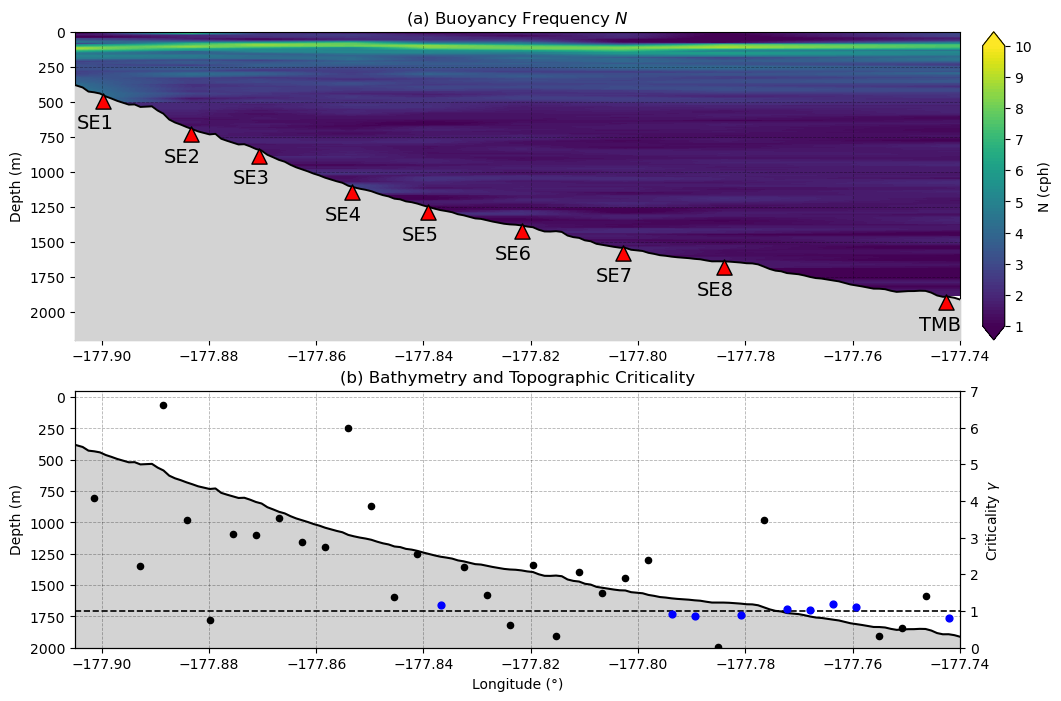

In [89]:
from scipy.interpolate import interp1d
import numpy as np

# =====================================================
# EXTEND LONGITUDE GRID EASTWARD
# =====================================================

dlon = np.median(np.diff(lon_tr))

lon_tr_ext = np.arange(
    lon_tr.min(),
    lon_tr.max() + 0.00005,
    dlon
)

# =====================================================
# EXTEND BATHYMETRY
# =====================================================

fH = interp1d(
    lon_tr,
    H_tr,
    bounds_error=False,
    fill_value="extrapolate"
)

H_tr_ext = fH(lon_tr_ext)

# =====================================================
# INTERPOLATE N ONTO EXTENDED LONGITUDE GRID
# =====================================================

N_cph_grid_lon = np.full(
    (len(z_grid), len(lon_tr_ext)),
    np.nan
)

for k in range(len(z_grid)):

    row = N_cph_grid[k, :]
    good = np.isfinite(row)

    if np.sum(good) < 2:
        continue

    fN = interp1d(
        x_grid[good],
        row[good],
        bounds_error=False,
        fill_value="extrapolate"
    )

    N_cph_grid_lon[k, :] = fN(lon_tr_ext)

# =====================================================
# FILL TO SEABED (+50 m BUFFER)
# Extend deepest valid N downward
# =====================================================

for i, H in enumerate(H_tr_ext):

    prof = N_cph_grid_lon[:, i]

    good = np.where(np.isfinite(prof))[0]

    if len(good) == 0:
        continue

    last_idx = good[-1]

    # fill ALL NaNs below deepest valid point
    prof[last_idx:] = prof[last_idx]

    N_cph_grid_lon[:, i] = prof

# =====================================================
# MESHGRID FOR PLOTTING
# =====================================================

LON_TR, DEPTH_TR = np.meshgrid(
    lon_tr_ext,
    z_grid
)

# =====================================================
# CRITICALITY
# =====================================================

lat0 = np.nanmean(lat_tr)

x_m = (
    (lon_tr_ext - lon_tr_ext[0])
    * 111320
    * np.cos(np.deg2rad(lat0))
)

bathy_slope = np.abs(
    np.gradient(H_tr_ext, x_m)
)

# =====================================================
# BOTTOM N (BOTTOM 5 m)
# =====================================================

N_bottom = np.full(
    len(lon_tr_ext),
    np.nan
)

for i, H in enumerate(H_tr_ext):

    mask = (
        (z_grid >= max(0, H - 5))
        & (z_grid <= H)
    )

    vals = N_cph_grid_lon[mask, i]

    if np.any(np.isfinite(vals)):
        N_bottom[i] = np.nanmean(vals)

# =====================================================
# FILL GAPS IN BOTTOM N
# =====================================================

good = np.isfinite(N_bottom)

if np.sum(good) > 2:

    fNbot = interp1d(
        lon_tr_ext[good],
        N_bottom[good],
        bounds_error=False,
        fill_value="extrapolate"
    )

    N_bottom = fNbot(lon_tr_ext)

# =====================================================
# M2 CRITICALITY
# =====================================================

omega = 1.405e-4

f_cor = (
    2
    * 7.292115e-5
    * np.sin(np.deg2rad(lat0))
)

N_rad = N_bottom * (2 * np.pi / 3600)

ray_slope = np.full_like(
    N_rad,
    np.nan
)

good = (
    np.isfinite(N_rad)
    & (N_rad > omega)
)

ray_slope[good] = np.sqrt(
    (omega**2 - f_cor**2)
    / (N_rad[good]**2 - omega**2)
)

criticality_tr = bathy_slope / ray_slope

criticality_tr[~np.isfinite(criticality_tr)] = np.nan


step = 4

lon_plot = lon_tr_ext[::step]
crit_plot = criticality_tr[::step]

# =====================================================
# STATIONS
# =====================================================

plot_stations = station_N[
    station_N['station_label'] != 'TMC'
].copy()

station_lon = (
    df.groupby('station_label')['longitude_deg']
      .mean()
)

plot_stations['lon'] = (
    plot_stations['station_label']
    .map(station_lon)
)

plot_stations['depth'] = np.interp(
    plot_stations['lon'],
    lon_tr_ext,
    H_tr_ext
)

from scipy.interpolate import CubicSpline

x_sta = plot_stations["lon"].values

print("Original grid:", len(lon_tr))
print("Extended grid:", len(lon_tr_ext))
print("Original xmax:", lon_tr.max())
print("Extended xmax:", lon_tr_ext.max())


# =====================================================
# Figure
# =====================================================

fig = plt.figure(figsize=(12, 8))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[40, 1],
    height_ratios=[1.2, 1],
    hspace=0.18,
    wspace=0.05
)

ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0], sharex=ax_top)
cax = fig.add_subplot(gs[0, 1])

# =====================================================
# TOP PANEL: N
# =====================================================

cf = ax_top.contourf(
    LON_TR,
    DEPTH_TR,
    N_cph_grid_lon,
    levels=np.arange(1, 10.1, 0.1),
    cmap='viridis',
    extend='both'
)

ax_top.fill_between(
    lon_tr_ext,
    H_tr_ext,
    2200,
    color='lightgrey',
    zorder=10
)

ax_top.plot(
    lon_tr_ext,
    H_tr_ext,
    color='k',
    lw=1.4,
    zorder=11
)

# Station markers
ax_top.scatter(
    plot_stations['lon'],
    plot_stations['depth'] + 40,
    marker='^',
    s=120,
    color='red',
    edgecolor='k',
    zorder=20
)

for _, row in plot_stations.iterrows():

    ax_top.text(
        row['lon'] - 0.005,
        row['depth'] + 200,
        row['station_label'],
        fontsize=14,
        color='black',
        ha='left',
        va='center',
        zorder=30
    )

ax_top.grid(
    True,
    linestyle='--',
    linewidth=0.6,
    color='k',
    alpha=0.3
)

ax_top.set_ylabel('Depth (m)')
ax_top.set_title('(a) Buoyancy Frequency $N$')
ax_top.set_ylim(1890, -50)

cbar = fig.colorbar(cf, cax=cax)
cbar.set_label('N (cph)')

# =====================================================
# BOTTOM PANEL: BATHYMETRY
# =====================================================

ax_bot.fill_between(
    lon_tr_ext,
    H_tr_ext,
    np.nanmax(H_tr_ext),
    color='lightgray'
)

ax_bot.plot(
    lon_tr_ext,
    H_tr_ext,
    color='k',
    lw=1.5
)

ax_bot.invert_yaxis()

ax_bot.grid(
    True,
    linestyle='--',
    linewidth=0.6,
    color='k',
    alpha=0.3
)

# =====================================================
# CRITICALITY
# =====================================================

ax_cr = ax_bot.twinx()

near = (crit_plot >= 0.8) & (crit_plot < 1.2)
2
sub = crit_plot < 0.8
3
sup = crit_plot > 1.2

# all points
ax_cr.scatter(
    lon_plot,
    crit_plot,
    color='k',
    s=8,
    alpha=0.4,
    zorder=1
)

# colored subsets
ax_cr.scatter(
    lon_plot[sub],
    crit_plot[sub],
    color='black',
    s=20,
    zorder=5
)

ax_cr.scatter(
    lon_plot[near],
    crit_plot[near],
    color='blue',
    s=24,
    zorder=6
)

ax_cr.scatter(
    lon_plot[sup],
    crit_plot[sup],
    color='black',
    s=20,
    zorder=5
)

ax_cr.axhline(
    1,
    color='k',
    ls='--',
    lw=1.2
)

ax_cr.set_ylabel(r'Criticality $\gamma$')
ax_cr.set_ylim(0, 7)

# =====================================================
# AXES
# =====================================================

ax_top.set_xlim(
    -177.905,
    -177.739,
    
)


ax_top.set_ylim(2201, 0)

ax_bot.set_xlim(
    -177.905,
    -177.74,
)

ax_bot.set_ylim(2000, -50)

ax_bot.set_xlabel('Longitude (°)')
ax_bot.set_ylabel('Depth (m)')
ax_bot.set_title('(b) Bathymetry and Topographic Criticality')

plt.show()

In [90]:
N_cph_grid_lon.max()

np.float64(13.183121392936673)

Original grid: 200
Extended grid: 200
Original xmax: -177.72597254426034
Extended xmax: -177.7259725442618


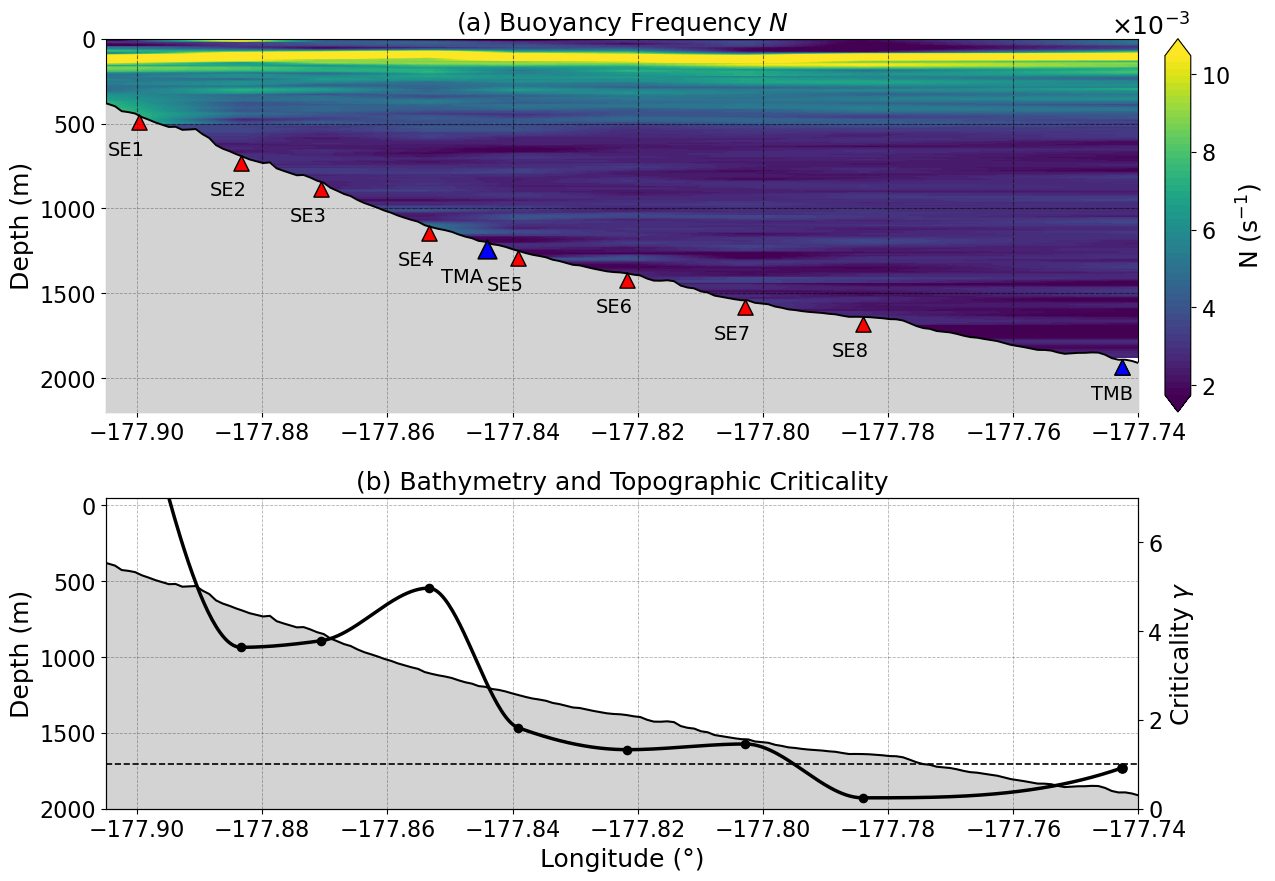

In [118]:
from scipy.interpolate import interp1d, PchipInterpolator
import numpy as np

# =====================================================
# EXTEND LONGITUDE GRID EASTWARD
# =====================================================

dlon = np.median(np.diff(lon_tr))

lon_tr_ext = np.arange(
    lon_tr.min(),
    lon_tr.max() + 0.00005,
    dlon
)

# =====================================================
# EXTEND BATHYMETRY
# =====================================================

fH = interp1d(
    lon_tr,
    H_tr,
    bounds_error=False,
    fill_value="extrapolate"
)

H_tr_ext = fH(lon_tr_ext)

# =====================================================
# INTERPOLATE N ONTO EXTENDED LONGITUDE GRID
# =====================================================

N_cph_grid_lon = np.full(
    (len(z_grid), len(lon_tr_ext)),
    np.nan
)

for k in range(len(z_grid)):

    row = N_cph_grid[k, :]
    good = np.isfinite(row)

    if np.sum(good) < 2:
        continue

    fN = interp1d(
        x_grid[good],
        row[good],
        bounds_error=False,
        fill_value="extrapolate"
    )

    N_cph_grid_lon[k, :] = fN(lon_tr_ext)

# =====================================================
# FILL TO SEABED
# =====================================================

for i, H in enumerate(H_tr_ext):

    prof = N_cph_grid_lon[:, i]

    good = np.where(np.isfinite(prof))[0]

    if len(good) == 0:
        continue

    last_idx = good[-1]

    prof[last_idx:] = prof[last_idx]

    N_cph_grid_lon[:, i] = prof

# =====================================================
# MESHGRID FOR PLOTTING
# =====================================================

LON_TR, DEPTH_TR = np.meshgrid(
    lon_tr_ext,
    z_grid
)

# =====================================================
# CRITICALITY
# =====================================================

lat0 = np.nanmean(lat_tr)

x_m = (
    (lon_tr_ext - lon_tr_ext[0])
    * 111320
    * np.cos(np.deg2rad(lat0))
)

bathy_slope = np.abs(
    np.gradient(H_tr_ext, x_m)
)

# =====================================================
# BOTTOM N (BOTTOM 5 m)
# =====================================================

N_bottom = np.full(
    len(lon_tr_ext),
    np.nan
)

for i, H in enumerate(H_tr_ext):

    mask = (
        (z_grid >= max(0, H - 5))
        & (z_grid <= H)
    )

    vals = N_cph_grid_lon[mask, i]

    if np.any(np.isfinite(vals)):
        N_bottom[i] = np.nanmean(vals)

# =====================================================
# FILL GAPS IN BOTTOM N
# =====================================================

good = np.isfinite(N_bottom)

if np.sum(good) > 2:

    fNbot = interp1d(
        lon_tr_ext[good],
        N_bottom[good],
        bounds_error=False,
        fill_value="extrapolate"
    )

    N_bottom = fNbot(lon_tr_ext)

# =====================================================
# M2 CRITICALITY
# =====================================================

omega = 1.405e-4

f_cor = (
    2
    * 7.292115e-5
    * np.sin(np.deg2rad(lat0))
)

N_rad = N_bottom * (2 * np.pi / 3600)

ray_slope = np.full_like(
    N_rad,
    np.nan
)

good = (
    np.isfinite(N_rad)
    & (N_rad > omega)
)

ray_slope[good] = np.sqrt(
    (omega**2 - f_cor**2)
    / (N_rad[good]**2 - omega**2)
)

criticality_tr = bathy_slope / ray_slope
criticality_tr[~np.isfinite(criticality_tr)] = np.nan

# =====================================================
# STATIONS
# =====================================================

plot_stations = station_N[
    station_N['station_label'] != 'TMC'
].copy()

station_lon = (
    df.groupby('station_label')['longitude_deg']
      .mean()
)

plot_stations['lon'] = (
    plot_stations['station_label']
    .map(station_lon)
)

plot_stations['depth'] = np.interp(
    plot_stations['lon'],
    lon_tr_ext,
    H_tr_ext
)

# =====================================================
# CRITICALITY AT CTD STATIONS + 2 POINTS BETWEEN EACH
# =====================================================

x_ctd = np.sort(
    plot_stations["lon"].values
)

# build list of CTD stations plus 2 intermediate points
x_pts = [x_ctd[0]]


n_between = 0

x_pts = [x_ctd[0]]

for i in range(len(x_ctd) - 1):

    x1 = x_ctd[i]
    x2 = x_ctd[i + 1]

    for j in range(1, n_between + 1):
        x_pts.append(
            x1 + j * (x2 - x1) / (n_between + 1)
        )

    x_pts.append(x2)



# for i in range(len(x_ctd) - 1):  # 2 points

    # x1 = x_ctd[i]
    # x2 = x_ctd[i + 1]

    # # 2 equally spaced points between casts
    # x_pts.extend([
    #     x1 + (x2 - x1) / 3,
    #     x1 + 2 * (x2 - x1) / 3,
    #     x2
    # ])

# for i in range(len(x_ctd) - 1): # 1 point

#     x1 = x_ctd[i]
#     x2 = x_ctd[i + 1]

#     x_pts.extend([
#         x1 + (x2 - x1) / 2,
#         x2
#     ])

# for i in range(len(x_ctd) - 1):    #3 points

#     x1 = x_ctd[i]
#     x2 = x_ctd[i + 1]

#     x_pts.extend([
#         x1 + (x2 - x1) / 4,
#         x1 + 2 * (x2 - x1) / 4,
#         x1 + 3 * (x2 - x1) / 4,
#         x2
#     ])

x_pts = np.array(x_pts)

# interpolate criticality onto those locations
y_pts = np.interp(
    x_pts,
    lon_tr_ext,
    criticality_tr
)

# smooth curve through points
curve = PchipInterpolator(
    x_pts,
    y_pts
)

x_smooth = np.linspace(
    x_pts.min(),
    x_pts.max(),
    500
)

y_smooth = curve(x_smooth)

print("Original grid:", len(lon_tr))
print("Extended grid:", len(lon_tr_ext))
print("Original xmax:", lon_tr.max())
print("Extended xmax:", lon_tr_ext.max())

# =====================================================
# FIGURE
# =====================================================

fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[40, 1],
    height_ratios=[1.2, 1],
    hspace=0.25,
    wspace=0.05
)

ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0], sharex=ax_top)
cax = fig.add_subplot(gs[0, 1])

# =====================================================
# TOP PANEL: N
# =====================================================
# cph -> rad s^-1

N_si_grid_lon = (
    N_cph_grid_lon
    * (2 * np.pi / 3600)
)

levels = np.arange(
    1, 6.1, 0.1
) * (2*np.pi/3600)


cf = ax_top.contourf(
    LON_TR,
    DEPTH_TR,
    N_si_grid_lon,
    levels=levels,
    cmap='viridis',
    extend='both'
)

ax_top.fill_between(
    lon_tr_ext,
    H_tr_ext,
    2200,
    color='lightgrey',
    zorder=10
)

ax_top.plot(
    lon_tr_ext,
    H_tr_ext,
    color='k',
    lw=1.4,
    zorder=11
)


tma_lon = -177.84402
tma_depth = np.interp(
    tma_lon,
    lon_tr_ext,
    H_tr_ext
)

# all CTD stations (red)

ax_top.scatter(
    plot_stations['lon'],
    plot_stations['depth'] + 40,
    marker='^',
    s=120,
    color='red',
    edgecolor='k',
    zorder=20
)

# TMB only (blue)

tmb = plot_stations[
    plot_stations['station_label'] == 'TMB'
]

ax_top.scatter(
    tmb['lon'],
    tmb['depth'] + 40,
    marker='^',
    s=120,
    color='blue',
    edgecolor='k',
    zorder=21
)

ax_top.scatter(
    tma_lon,
    tma_depth + 40,
    marker='^',
    s=180,
    color='blue',
    edgecolor='k',
    linewidth=1.2,
    zorder=25
)

ax_top.text(
    tma_lon - 0.004,      # further left
    tma_depth + 200,      # lower
    "TMA",
    color='black',
    fontsize=14,
    ha='center',
    va='center',
    zorder=30
)

for _, row in plot_stations.iterrows():

    ax_top.text(
        row['lon'] - 0.005,
        row['depth'] + 200,
        row['station_label'],
        fontsize=14,
        color='black',
        ha='left',
        va='center',
        zorder=30
    )

ax_top.grid(
    True,
    linestyle='--',
    linewidth=0.6,
    color='k',
    alpha=0.3
)

ax_top.set_ylabel('Depth (m)')
ax_top.set_title('(a) Buoyancy Frequency $N$')

cbar = fig.colorbar(cf, cax=cax)

# =====================================================
# BOTTOM PANEL: BATHYMETRY
# =====================================================

ax_bot.fill_between(
    lon_tr_ext,
    H_tr_ext,
    np.nanmax(H_tr_ext),
    color='lightgray'
)

ax_bot.plot(
    lon_tr_ext,
    H_tr_ext,
    color='k',
    lw=1.5
)

ax_bot.invert_yaxis()

ax_bot.grid(
    True,
    linestyle='--',
    linewidth=0.6,
    color='k',
    alpha=0.3
)

# =====================================================
# CRITICALITY
# =====================================================

# =====================================================
# CRITICALITY
# =====================================================

ax_cr = ax_bot.twinx()

# smooth line
ax_cr.plot(
    x_smooth,
    y_smooth,
    color='k',
    lw=2.5,
    zorder=4
)

# classify points
near = (y_pts >= 0.8) & (y_pts <= 1.2)

# points used for curve fit
ax_cr.scatter(
    x_pts[~near],
    y_pts[~near],
    color='k',
    s=35,
    zorder=5
)

ax_cr.scatter(
    x_pts[near],
    y_pts[near],
    color='k',
    edgecolor='k',
    s=45,
    zorder=6
)

ax_cr.axhline(
    1,
    color='k',
    ls='--',
    lw=1.2
)

ax_cr.set_ylabel(r'Criticality $\gamma$')
ax_cr.set_ylim(0, 7)

# =====================================================
# AXES
# =====================================================

ax_top.set_xlim(
    -177.905,
    -177.739
)

ax_top.set_ylim(2201, 0)

ax_bot.set_xlim(
    -177.905,
    -177.74
)

ax_bot.set_ylim(2000, -50)

ax_bot.set_xlabel('Longitude (°)')
ax_bot.set_ylabel('Depth (m)')
ax_bot.set_title('(b) Bathymetry and Topographic Criticality')



ax_top.tick_params(axis='both', labelsize=16)
ax_bot.tick_params(axis='both', labelsize=16)
ax_cr.tick_params(axis='y', labelsize=16)

cbar.ax.tick_params(labelsize=16)

ax_top.set_ylabel('Depth (m)', fontsize=18)
ax_bot.set_xlabel('Longitude (°)', fontsize=18)
ax_bot.set_ylabel('Depth (m)', fontsize=18)
ax_cr.set_ylabel(r'Criticality $\gamma$', fontsize=18)

ax_top.set_title('(a) Buoyancy Frequency $N$', fontsize=18)
ax_bot.set_title('(b) Bathymetry and Topographic Criticality', fontsize=18)

cbar.set_label('N (cph)', fontsize=18)

ax_top.set_axisbelow(False)


from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -3))
cbar.ax.yaxis.get_offset_text().set_fontsize(18)
cbar.formatter = formatter
cbar.update_ticks()
cbar.set_label(
    r'N (s$^{-1}$)',
    fontsize=18
)
cbar.set_ticks(np.arange(0.002, 0.011, 0.002))

ax_top.grid(
    True,
    linestyle='--',
    linewidth=0.8,
    color='k',
    alpha=0.4,
    zorder=1000
)

for x in ax_top.get_xticks():
    ax_top.axvline(
        x,
        color='k',
        ls='--',
        lw=0.6,
        alpha=0.3,
        zorder=100
    )

for y in ax_top.get_yticks():
    ax_top.axhline(
        y,
        color='k',
        ls='--',
        lw=0.6,
        alpha=0.3,
        zorder=100
    )
    
plt.savefig(
    'fig08.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [116]:
lat_line = np.interp(
    lon0,
    lon_tr,
    lat_tr
)

dy_km = (
    lat_line - lat0
) * 111.32

print(f"Cross-track offset = {dy_km:.2f} km")

Cross-track offset = -1.70 km


In [93]:
print("dlon =", dlon, "degrees")
dx = dlon * 111320 * np.cos(np.deg2rad(lat0))
print("dx =", dx, "m")

dlon = 0.0010761135312691295 degrees
dx = 104.43314634830686 m


In [94]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Physical constants
# --------------------------------------------------
g = 9.81
rho0 = 1025.0

omega = 2 * np.pi / (12.42 * 3600)  # M2 tide [rad s^-1]
omega2 = omega**2

# --------------------------------------------------
# Station grouping variable
# --------------------------------------------------
station_col = 'station_label'  # or 'station' if that's the correct one

# --------------------------------------------------
# Coriolis frequency
# --------------------------------------------------
Omega = 7.2921159e-5



df['f'] = 2 * Omega * np.sin(np.deg2rad(df['latitude_deg']))
df['f2'] = df['f']**2

# --------------------------------------------------
# Compute N²
# --------------------------------------------------
def compute_N2(profile):

    profile = profile.sort_values('depth_m').copy()

    depth = profile['depth_m'].to_numpy()
    rho = profile['rho'].to_numpy()

    if len(profile) < 3:
        profile['N2'] = np.nan
        return profile

    drho_dz = np.gradient(rho, depth)

    profile['N2'] = (g / rho0) * drho_dz

    return profile


# --------------------------------------------------
# Vertical smoothing
# --------------------------------------------------
def smooth_N2(profile, window=3):

    profile = profile.sort_values('depth_m').copy()

    profile['N2_smooth'] = (
        profile['N2']
        .rolling(window=window, center=True, min_periods=1)
        .mean()
    )

    return profile




# --------------------------------------------------
# Bottom-averaged N²
# --------------------------------------------------
def bottom_avg_N2(profile, depth_range=5):

    profile = profile.sort_values('depth_m').copy()

    max_depth = profile['depth_m'].max()

    bottom = profile[
        (profile['depth_m'] >= max_depth - depth_range)
        & np.isfinite(profile['N2_smooth'])
    ]

    profile['N2_bottom'] = (
        bottom['N2_smooth'].median()
        if len(bottom) > 0
        else np.nan
    )

    return profile

profiles = []

for station, profile in df.groupby('station_label'):

    profile = compute_N2(profile)

    profile.loc[profile['N2'] <= omega2, 'N2'] = np.nan

    profile = smooth_N2(profile)

    profile = bottom_avg_N2(profile)

    profiles.append(profile)

df = pd.concat(profiles, ignore_index=True)


# --------------------------------------------------
# M2 internal tide phase speed
# --------------------------------------------------
df['c_M2'] = np.nan

valid = (
    (df['N2_bottom'] > omega2) &
    (omega2 > df['f2']) & (df['N2_bottom']>0)
)

df.loc[valid, 'c_M2'] = np.sqrt(
    (omega2 - df.loc[valid, 'f2']) /
    (df.loc[valid, 'N2_bottom'] - omega2)
)